[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/emmaruyiyang/MMAI-MemeSonic/blob/main/image-text-fusion/incongruity_aware_fusion.ipynb)

# Sentiment-Incongruity-Aware Fusion for Meme Understanding

This notebook implements a **Sentiment-Incongruity-Aware Fusion** method on the MET-Meme dataset.
It can run standalone, independently of the main HW2 notebook.

### Motivation
Standard fusion methods (Concat, LMF, etc.) measure incongruity in raw **embedding space** —
capturing geometric distance between encoder outputs, not meaningful semantic tension.
Meme meaning, however, arises from the contradiction between **image sentiment** and **text sentiment**:
a cheerful image paired with a sarcastic caption. This method explicitly models that disagreement.

### Design
Each encoder output is projected into a 5-class **sentiment probability space**. The fusion computes:
- `align`: `(img_emb + txt_emb) / 2` — shared content signal
- `sentiment_incong`: `|img_sentiment - txt_sentiment|` — per-class emotional disagreement
- `incong_gate`: a learned scalar (per sample) controlling how much incongruity matters

Final representation: `[align(64) | gate * sentiment_incong(5)]` → MLP head

In [31]:
# Install dependencies (run once; skip if already installed)
!pip install -q torch==2.3.1 torchvision==0.18.1
!pip install -q transformers==4.40.0 datasets
!pip install memory_profiler

import sys


!git clone https://github.com/pliang279/MultiBench.git

# MultiBench is located one level up from this notebook.
# MultiBench/datasets/ shadows the HuggingFace 'datasets' package,
# so we import HuggingFace datasets first, then add MultiBench to sys.path.
_mb = [p for p in sys.path if 'MultiBench' in p]
for p in _mb:
    sys.path.remove(p)

from datasets import load_dataset  # now safely resolves to HuggingFace

# sys.path.insert(0, '../MultiBench')  # MultiBench is at hw2/MultiBench/
sys.path.insert(0, './MultiBench')

Cloning into 'MultiBench'...
remote: Enumerating objects: 6943, done.
remote: Counting objects: 100% (402/402), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 6943 (delta 363), reused 341 (delta 341), pack-reused 6541 (from 1)
Receiving objects: 100% (6943/6943), 51.03 MiB | 14.73 MiB/s, done.
Resolving deltas: 100% (4281/4281), done.


In [32]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import BertTokenizer, BertModel
from unimodals.common_models import MLP
from training_structures.Supervised_Learning import train, test, MMDL

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classes = 5
print(f'Using device: {device}')

Using device: cpu


## 1. Dataset
Load the MET-Meme dataset from HuggingFace and extract BERT [CLS] embeddings for text.
Embeddings are cached to disk so they are only computed once.

In [7]:
hf = load_dataset('Emmaruyi/met-meme-filtered')

# ResNet-50 expects 224x224 and ImageNet normalization
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

class CachedDataset(Dataset):
    def __init__(self, hf_split, text_embeddings=None):
        self.data = hf_split
        self.text_embeddings = text_embeddings

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row   = self.data[idx]
        image = transform(row['image'].convert('RGB'))
        text  = self.text_embeddings[idx] if self.text_embeddings is not None else row['caption']
        label = row['intention_num'] - 1
        return image, text, label

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/192M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/23.0M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/22.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2711 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/338 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/340 [00:00<?, ? examples/s]

In [8]:
def extract_text_embeddings(captions, device='cpu'):
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    bert = BertModel.from_pretrained('bert-base-uncased').to(device)
    bert.eval()
    embeddings = []
    with torch.no_grad():
        for caption in tqdm(captions, desc='Extracting BERT embeddings'):
            inputs = tokenizer(caption, return_tensors='pt', truncation=True,
                               max_length=128, padding='max_length').to(device)
            outputs = bert(**inputs)
            embeddings.append(outputs.last_hidden_state[:, 0, :].squeeze(0).cpu())
    return torch.stack(embeddings)


EMB_CACHE = 'all_text_emb.pt'

if os.path.exists(EMB_CACHE):
    print('Loading cached BERT embeddings...')
    all_text_emb = torch.load(EMB_CACHE)
else:
    print('Extracting BERT embeddings (this takes a few minutes)...')
    all_text_emb = {
        'train':      extract_text_embeddings(hf['train']['caption'],      device),
        'validation': extract_text_embeddings(hf['validation']['caption'], device),
        'test':       extract_text_embeddings(hf['test']['caption'],       device),
    }
    torch.save(all_text_emb, EMB_CACHE)
    print(f'Saved to {EMB_CACHE}')

trainset = CachedDataset(hf['train'],      all_text_emb['train'])
valset   = CachedDataset(hf['validation'], all_text_emb['validation'])
testset  = CachedDataset(hf['test'],       all_text_emb['test'])

traindata = DataLoader(trainset, batch_size=64, shuffle=True)
validdata = DataLoader(valset,   batch_size=64)
testdata  = DataLoader(testset,  batch_size=64)

print(f'Train: {len(trainset)}, Val: {len(valset)}, Test: {len(testset)}')


Extracting BERT embeddings (this takes a few minutes)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Extracting BERT embeddings: 100%|██████████| 340/340 [00:03<00:00, 108.10it/s]

Saved to all_text_emb.pt
Train: 2711, Val: 338, Test: 340


## 2. Encoders

- **ImageEncoder**: ResNet-50 pretrained on ImageNet, backbone frozen, only the final projection layer is trained.
- **TextEncoder**: BERT `bert-base-uncased`, backbone frozen, only a linear projection is trained. The 768-dim `[CLS]` embeddings are already cached from the dataset step.

In [26]:
import torchvision.models as tv_models

class ImageEncoder(nn.Module):
    """ResNet-50 pretrained on ImageNet, backbone frozen, projection trainable."""
    def __init__(self, output_dim=64):
        super().__init__()
        resnet = tv_models.resnet50(weights=tv_models.ResNet50_Weights.IMAGENET1K_V1)
        # Remove the final classification head; keep everything up to avgpool
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])  # -> (batch, 2048, 1, 1)
        for p in self.backbone.parameters():
            p.requires_grad = False
        self.proj = nn.Linear(2048, output_dim)

    def forward(self, x):
        with torch.no_grad():
            feat = self.backbone(x).flatten(1)  # (batch, 2048)
        return self.proj(feat)                  # (batch, output_dim)


class TextEncoder(nn.Module):
    """BERT bert-base-uncased, backbone frozen. Input: cached 768-dim [CLS] embeddings."""
    def __init__(self, input_dim=768, output_dim=64):
        super().__init__()
        # Backbone is already applied offline (BERT embeddings are pre-cached).
        # This layer just projects the cached 768-dim vector.
        self.proj = nn.Linear(input_dim, output_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.proj(x))          # (batch, output_dim)

## 3. Sentiment-Incongruity-Aware Fusion

Unlike embedding-space incongruity (e.g. `|img_emb - txt_emb|` which mixes unrelated feature dimensions),
this fusion first maps each modality to a **sentiment probability distribution** and then computes disagreement there.

The intuition: if the image looks positive but the text reads negative, the `sentiment_incong` vector will have
large values at those conflicting classes — a direct signal of the meme's ironic tension.

In [40]:
class SentimentIncongruityFusion(nn.Module):
    """
    Projects each modality into sentiment probability space,
    then computes emotional disagreement as the incongruity signal.
    Output dim: input_dim + num_sentiments = 64 + 5 = 69
    """
    def __init__(self, input_dim=64, num_sentiments=5):
        super().__init__()
        self.img_sentiment = nn.Linear(input_dim, num_sentiments)
        self.txt_sentiment = nn.Linear(input_dim, num_sentiments)
        # Gate: learn how much incongruity matters per sample
        self.incong_gate = nn.Sequential(
            nn.Linear(input_dim * 2, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        img, txt = x[0], x[1]  # (batch, 64) each

        img_sent = F.softmax(self.img_sentiment(img), dim=-1)  # (batch, 5)
        txt_sent = F.softmax(self.txt_sentiment(txt), dim=-1)  # (batch, 5)

        # Emotional disagreement: where do the two modalities disagree?
        sentiment_incong = torch.abs(img_sent - txt_sent)          # (batch, 5)

        gate  = self.incong_gate(torch.cat([img, txt], dim=-1))    # (batch, 1)
        align = (img + txt) / 2                                     # (batch, 64)

        return torch.cat([align, gate * sentiment_incong], dim=-1) # (batch, 69)


## 4. Unimodal Baselines

Train image-only and text-only models using the same pretrained encoders, for direct comparison with the fusion model.

In [27]:
def train_unimodal(model, modality_idx, name, epochs=10, lr=5e-4):
    """Train a unimodal model, return best test accuracy."""
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    criterion = nn.CrossEntropyLoss()
    best_val_acc, best_state = 0.0, None

    for epoch in range(epochs):
        model.train()
        for batch in traindata:
            x = batch[modality_idx].float().to(device)
            y = batch[2].long().to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for batch in validdata:
                x = batch[modality_idx].float().to(device)
                y = batch[2].long().to(device)
                correct += (model(x).argmax(1) == y).sum().item()
                total   += y.size(0)
        val_acc = correct / total
        print(f'  [{name}] Epoch {epoch+1:02d} — val acc: {val_acc:.4f}')
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for batch in testdata:
            x = batch[modality_idx].float().to(device)
            y = batch[2].long().to(device)
            correct += (model(x).argmax(1) == y).sum().item()
            total   += y.size(0)
    test_acc = 100 * correct / total
    print(f'  [{name}] Test Accuracy: {test_acc:.2f}%')
    return test_acc


# Image-only: ResNet-50 frozen backbone + projection + linear head
image_unimodal = nn.Sequential(
    ImageEncoder(output_dim=64),
    nn.Linear(64, num_classes)
)

# Text-only: BERT cached embedding + projection + linear head
text_unimodal = nn.Sequential(
    TextEncoder(output_dim=64),
    nn.Linear(64, num_classes)
)

unimodal_results = {}

print('='*45)
print('Training Unimodal-Image (ResNet-50 frozen)...')
print('='*45)
unimodal_results['Unimodal-Image'] = train_unimodal(image_unimodal, modality_idx=0, name='Image')

print()
print('='*45)
print('Training Unimodal-Text (BERT cached)...')
print('='*45)
unimodal_results['Unimodal-Text'] = train_unimodal(text_unimodal, modality_idx=1, name='Text')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 199MB/s]


Training Unimodal-Image (ResNet-50 frozen)...
  [Image] Epoch 01 — val acc: 0.3284
  [Image] Epoch 02 — val acc: 0.2811
  [Image] Epoch 03 — val acc: 0.4053
  [Image] Epoch 04 — val acc: 0.4172
  [Image] Epoch 05 — val acc: 0.3787
  [Image] Epoch 06 — val acc: 0.3521
  [Image] Epoch 07 — val acc: 0.4172
  [Image] Epoch 08 — val acc: 0.3491
  [Image] Epoch 09 — val acc: 0.2663
  [Image] Epoch 10 — val acc: 0.3195
  [Image] Test Accuracy: 42.35%

Training Unimodal-Text (BERT cached)...
  [Text] Epoch 01 — val acc: 0.4645
  [Text] Epoch 02 — val acc: 0.3225
  [Text] Epoch 03 — val acc: 0.4024
  [Text] Epoch 04 — val acc: 0.4083
  [Text] Epoch 05 — val acc: 0.4231
  [Text] Epoch 06 — val acc: 0.4260
  [Text] Epoch 07 — val acc: 0.3964
  [Text] Epoch 08 — val acc: 0.4231
  [Text] Epoch 09 — val acc: 0.4083
  [Text] Epoch 10 — val acc: 0.4083
  [Text] Test Accuracy: 46.47%


## 4. Training

In [ ]:
# incong_fusion   = SentimentIncongruityFusion(input_dim=64, num_sentiments=num_classes)
# incong_head     = MLP(69, 256, num_classes)  # 64 align + 5 sentiment incongruity
# incong_encoders = [ImageEncoder(output_dim=64), TextEncoder(output_dim=64)]

# print('Training Sentiment-Incongruity-Aware Fusion...')
# train(
#     incong_encoders, incong_fusion, incong_head,
#     traindata, validdata,
#     total_epochs=10,
#     task='classification',
#     optimtype=torch.optim.AdamW,
#     is_packed=False,
#     lr=5e-4,
#     save='incong_fusion.pt',
#     weight_decay=1e-3,
#     objective=torch.nn.CrossEntropyLoss(),
#     input_to_float=False
# )

# incong_model = torch.load('incong_fusion.pt').to(device)
# print('\n--- Test Results ---')
# test(
#     incong_model, testdata,
#     is_packed=False,
#     task='classification',
#     criterion=torch.nn.CrossEntropyLoss(),
#     no_robust=True
# )


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:02<00:00, 42.3MB/s]


Training Sentiment-Incongruity-Aware Fusion...
Epoch 0 train loss: tensor(1.2511, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 0 valid loss: tensor(1.2730, device='cuda:0') acc: 0.46745562130177515
Saving Best
Epoch 1 train loss: tensor(1.1675, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 1 valid loss: tensor(1.2585, device='cuda:0') acc: 0.3875739644970414
Epoch 2 train loss: tensor(1.1141, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 2 valid loss: tensor(1.3198, device='cuda:0') acc: 0.32840236686390534
Epoch 3 train loss: tensor(1.0785, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 3 valid loss: tensor(1.3524, device='cuda:0') acc: 0.32840236686390534
Epoch 4 train loss: tensor(1.0460, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 4 valid loss: tensor(1.3922, device='cuda:0') acc: 0.3254437869822485
Epoch 5 train loss: tensor(1.0525, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 5 valid loss: tensor(1.3621, device='cuda:0') acc: 0.31952662721893493
Epoch 6 train loss: tenso

## 5. Evaluation & Visualization

For each of 4 test samples, plot:
- **Image sentiment distribution** — what the image encoder "thinks" emotionally
- **Text sentiment distribution** — what the text encoder "thinks" emotionally
- **Incongruity** — the absolute difference: high bars = strong emotional conflict at that class

In [ ]:
# ── Test accuracy ─────────────────────────────────────────────────────────────
incong_model.eval()
correct, total = 0, 0
with torch.no_grad():
    for imgs, text, label in testdata:
        imgs  = imgs.float().to(device)
        text  = text.float().to(device)
        label = label.long().to(device)
        out   = incong_model([imgs, text])
        correct += (out.argmax(1) == label).sum().item()
        total   += label.size(0)
print(f'Test Accuracy: {100 * correct / total:.2f}%')

# ── Parameter count ───────────────────────────────────────────────────────────
def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

incong_full = MMDL(
    [ImageEncoder(output_dim=64), TextEncoder(output_dim=64)],
    SentimentIncongruityFusion(input_dim=64, num_sentiments=num_classes),
    MLP(69, 256, num_classes)
)
print(f'Total trainable parameters: {count_params(incong_full):,}')


Test Accuracy: 43.53%
Total trainable parameters: 200,336


In [ ]:
# ── Summary comparison ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

all_results = {
    **unimodal_results,
    'IncongruityFusion': 100 * correct / total,  # from eval_acc cell above
}

names = list(all_results.keys())
accs  = [all_results[n] for n in names]
colors = ['steelblue', 'darkorange', 'crimson']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(names, accs, color=colors, width=0.5, edgecolor='black', linewidth=0.5)

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Unimodal vs Sentiment-Incongruity-Aware Fusion\n(pretrained encoders, frozen backbone)')
ax.set_ylim(0, max(accs) + 8)
ax.axhline(y=20, color='gray', linestyle='--', linewidth=0.8, label='Random baseline (5-class)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('unimodal_vs_fusion.png', dpi=150)
plt.show()
print('Saved: unimodal_vs_fusion.png')

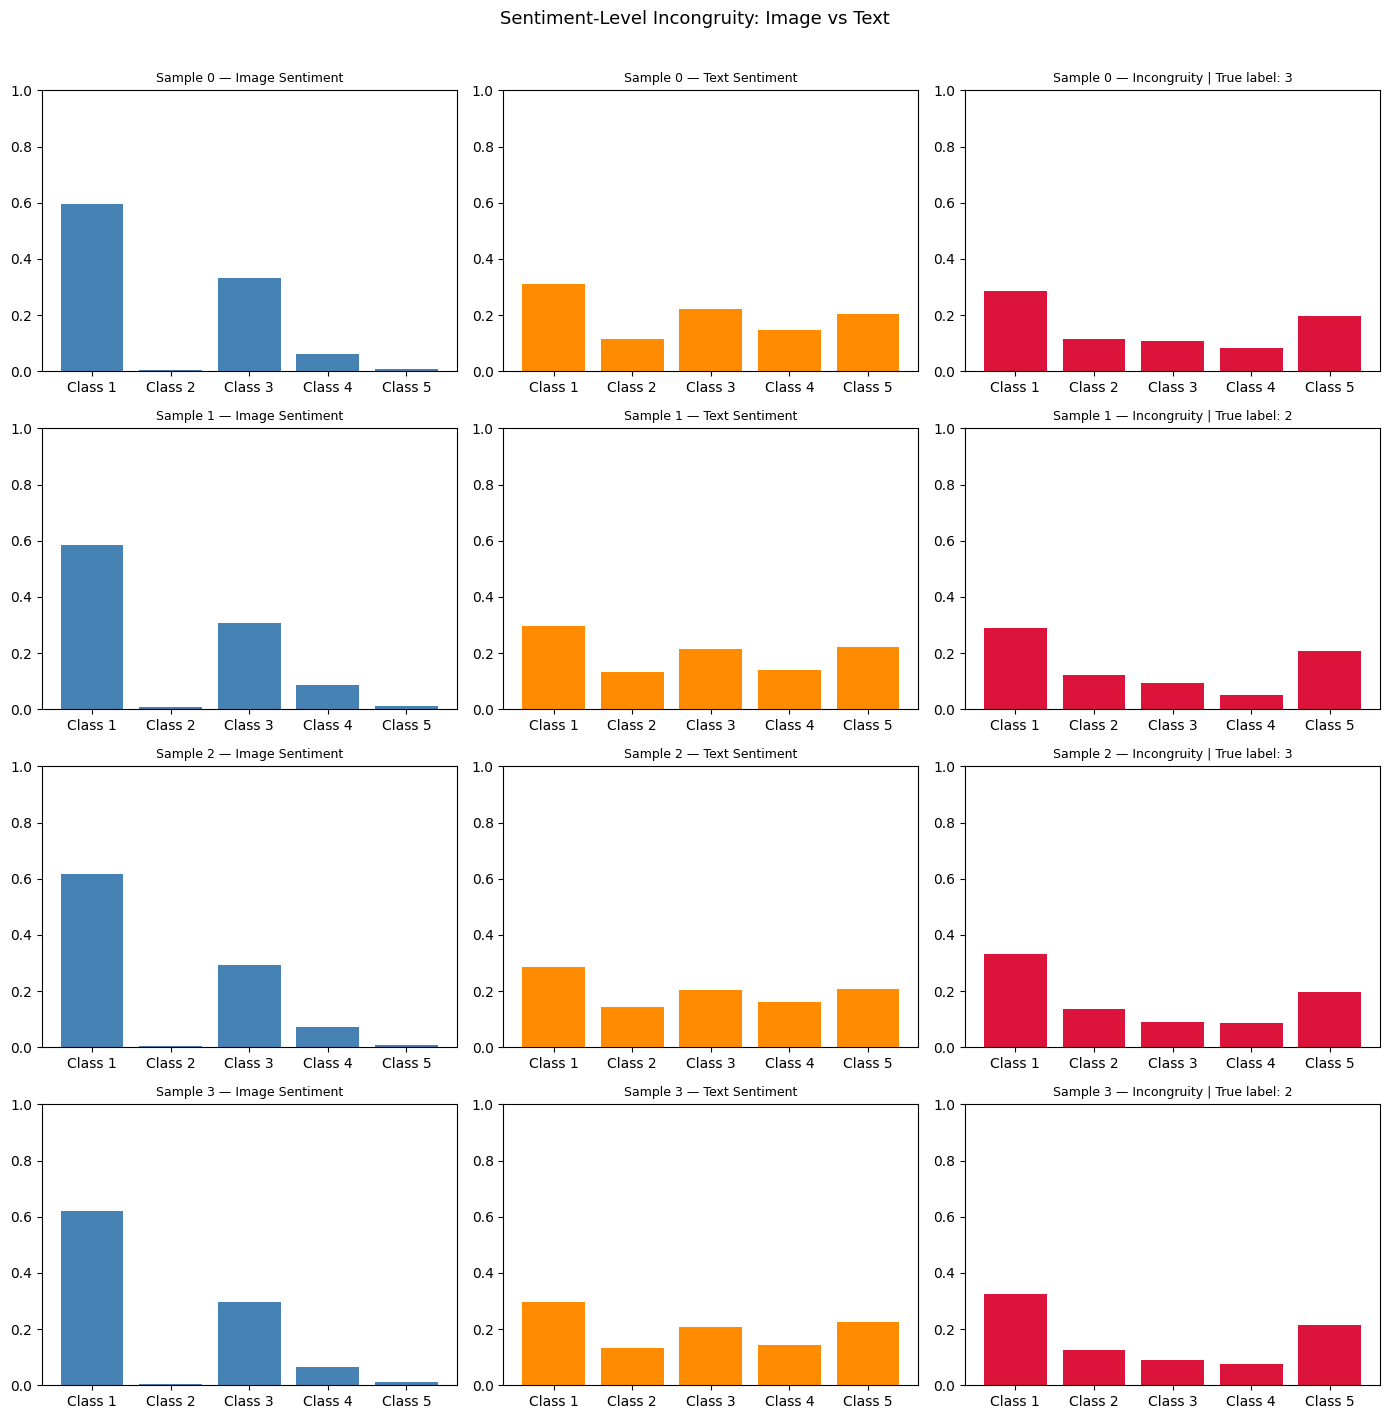

Saved: incongruity_sentiment_vis.png


In [ ]:
# ── Visualize sentiment distributions for 4 test samples ─────────────────────
incong_model.eval()
imgs, text, labels = next(iter(testdata))
imgs = imgs.float().to(device)
text = text.float().to(device)

enc_img  = incong_model.encoders[0].to(device)
enc_txt  = incong_model.encoders[1].to(device)
fuse_mod = incong_model.fuse.to(device)

with torch.no_grad():
    img_emb  = enc_img(imgs)
    txt_emb  = enc_txt(text)
    img_sent = F.softmax(fuse_mod.img_sentiment(img_emb), dim=-1).cpu().numpy()
    txt_sent = F.softmax(fuse_mod.txt_sentiment(txt_emb), dim=-1).cpu().numpy()
    incong   = abs(img_sent - txt_sent)

label_names = [f'Class {i+1}' for i in range(num_classes)]
fig, axes = plt.subplots(4, 3, figsize=(14, 14))

for i in range(4):
    axes[i, 0].bar(label_names, img_sent[i], color='steelblue')
    axes[i, 0].set_title(f'Sample {i} — Image Sentiment', fontsize=9)
    axes[i, 0].set_ylim(0, 1)

    axes[i, 1].bar(label_names, txt_sent[i], color='darkorange')
    axes[i, 1].set_title(f'Sample {i} — Text Sentiment', fontsize=9)
    axes[i, 1].set_ylim(0, 1)

    axes[i, 2].bar(label_names, incong[i], color='crimson')
    axes[i, 2].set_title(
        f'Sample {i} — Incongruity | True label: {labels[i].item()+1}', fontsize=9
    )
    axes[i, 2].set_ylim(0, 1)

plt.suptitle('Sentiment-Level Incongruity: Image vs Text', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('incongruity_sentiment_vis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: incongruity_sentiment_vis.png')


## 6. CLIP Embedding Space Visualization

We use CLIP (ViT-B/32) to embed image-text pairs into a **shared semantic space** — unlike BERT+ResNet which live in separate spaces, CLIP image and text embeddings are directly comparable via cosine similarity.

For 10 meme samples we visualize:
1. **Similarity matrix** — cosine similarity between all image-text pairs; diagonal = correct matches
2. **t-SNE** — image embeddings (squares) and text embeddings (circles) colored by sample index; good alignment = same-color pairs cluster together

In [3]:
!pip install -q git+https://github.com/openai/CLIP.git

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.2 MB/s eta 0:00:00


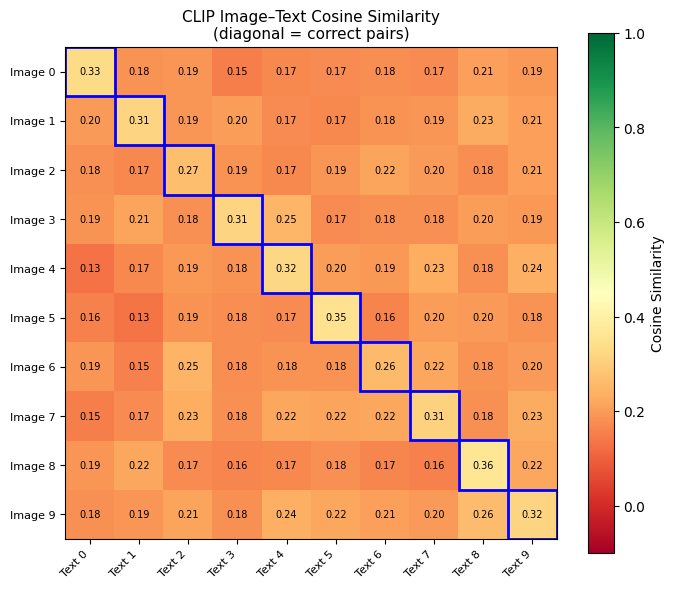

Mean diagonal (correct pairs) : 0.3152
Mean off-diagonal (wrong pairs): 0.1910
Alignment gap                  : 0.1241


In [11]:
import clip
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.manifold import TSNE
from PIL import Image as PILImage

# ── Load CLIP ─────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
clip_model, clip_preprocess = clip.load('ViT-B/32', device=device)
clip_model.eval()

# ── Sample 10 memes from test set ─────────────────────────────────────────────
N = 10
indices = list(range(N))  # change to random indices if preferred
samples = [hf['test'][i] for i in indices]

images   = [clip_preprocess(s['image'].convert('RGB')) for s in samples]
captions = [s['caption'] for s in samples]
labels   = [s['intention_num'] - 1 for s in samples]

image_input = torch.stack(images).to(device)                        # (10, 3, 224, 224)
text_input  = clip.tokenize(captions, truncate=True).to(device)     # (10, 77)

# ── Extract CLIP embeddings ───────────────────────────────────────────────────
with torch.no_grad():
    img_emb  = clip_model.encode_image(image_input)   # (10, 512)
    txt_emb  = clip_model.encode_text(text_input)     # (10, 512)

img_emb = torch.nn.functional.normalize(img_emb, dim=-1).cpu().numpy()
txt_emb = torch.nn.functional.normalize(txt_emb, dim=-1).cpu().numpy()

# ── 1. Cosine similarity matrix ───────────────────────────────────────────────
sim_matrix = img_emb @ txt_emb.T   # (10, 10)  row=image, col=text

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(sim_matrix, cmap='RdYlGn', vmin=-0.1, vmax=1.0)
plt.colorbar(im, ax=ax, label='Cosine Similarity')

ax.set_xticks(range(N))
ax.set_yticks(range(N))
ax.set_xticklabels([f'Text {i}' for i in range(N)], rotation=45, ha='right', fontsize=8)
ax.set_yticklabels([f'Image {i}' for i in range(N)], fontsize=8)
ax.set_title('CLIP Image–Text Cosine Similarity\n(diagonal = correct pairs)', fontsize=11)

# Annotate each cell with the value
for i in range(N):
    for j in range(N):
        ax.text(j, i, f'{sim_matrix[i, j]:.2f}',
                ha='center', va='center', fontsize=7,
                color='black' if abs(sim_matrix[i, j]) < 0.7 else 'white')

# Highlight diagonal
for i in range(N):
    ax.add_patch(plt.Rectangle((i - 0.5, i - 0.5), 1, 1,
                                fill=False, edgecolor='blue', linewidth=2))

plt.tight_layout()
plt.savefig('clip_similarity_matrix.png', dpi=150)
plt.show()

diag_mean = np.diag(sim_matrix).mean()
offdiag   = sim_matrix[~np.eye(N, dtype=bool)].mean()
print(f'Mean diagonal (correct pairs) : {diag_mean:.4f}')
print(f'Mean off-diagonal (wrong pairs): {offdiag:.4f}')
print(f'Alignment gap                  : {diag_mean - offdiag:.4f}')

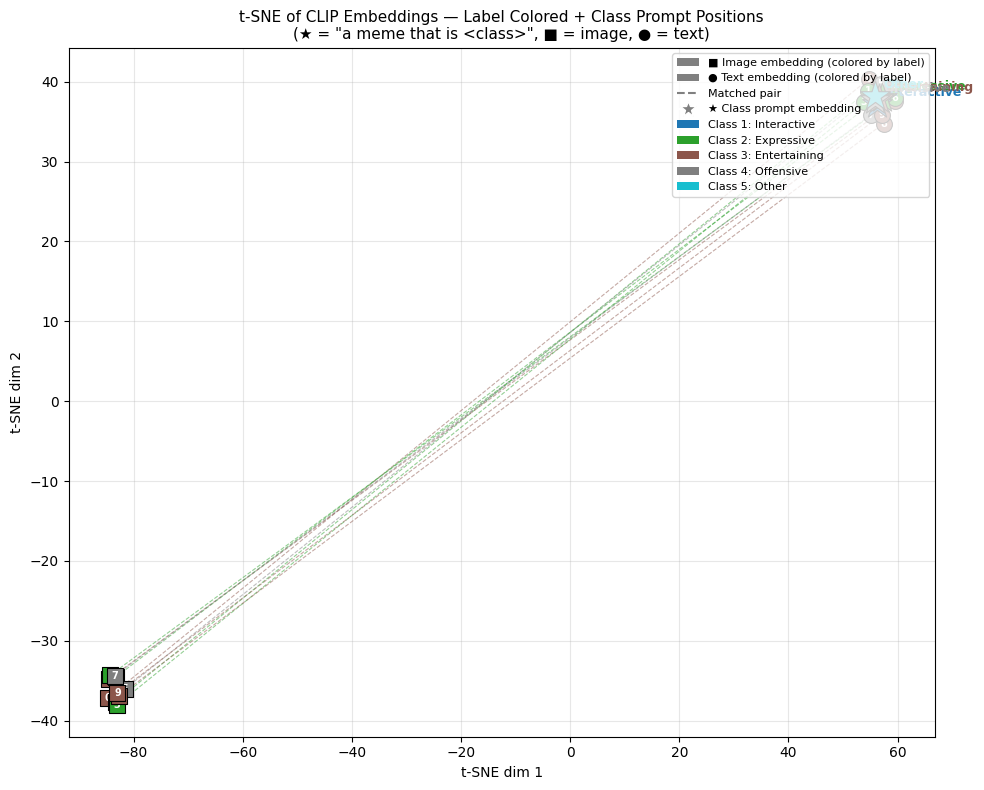

Saved: clip_tsne_enhanced.png

Nearest class prompt for each sample (cosine similarity):
Sample   True Label     Nearest Prompt    Sim
------------------------------------------------
0        Entertaining   img→Interactive 0.223
                        txt→Other      0.732
1        Expressive     img→Expressive 0.222
                        txt→Other      0.836
2        Entertaining   img→Other      0.260
                        txt→Entertaining 0.883
3        Expressive     img→Interactive 0.243
                        txt→Entertaining 0.830
4        Expressive     img→Interactive 0.267
                        txt→Other      0.845
5        Offensive      img→Expressive 0.237
                        txt→Interactive 0.838
6        Expressive     img→Entertaining 0.250
                        txt→Entertaining 0.877
7        Offensive      img→Interactive 0.271
                        txt→Interactive 0.835
8        Entertaining   img→Expressive 0.216
                        txt→Interacti

In [12]:
# ── Enhanced t-SNE: label coloring + class prompt embeddings ──────────────────
# Intention classes (1-indexed in dataset, 0-indexed here)
INTENTION_LABELS = [
    'Interactive',   # class 1
    'Expressive',    # class 2
    'Entertaining',  # class 3
    'Offensive',     # class 4
    'Other',         # class 5
]
intention_prompts = [f'a meme that is {lbl.lower()}' for lbl in INTENTION_LABELS]

# Encode class prompts with CLIP
prompt_tokens = clip.tokenize(intention_prompts, truncate=True).to(device)
with torch.no_grad():
    prompt_emb = clip_model.encode_text(prompt_tokens).float()  # (5, 512)
prompt_emb = F.normalize(prompt_emb, dim=-1).cpu().numpy()

# Stack: 10 image + 10 text + 5 class prompts = 25 points
all_emb_ext = np.concatenate([img_emb, txt_emb, prompt_emb], axis=0)  # (25, 512)

tsne2 = TSNE(n_components=2, perplexity=6, random_state=42, init='pca')
emb_2d_ext = tsne2.fit_transform(all_emb_ext)  # (25, 2)

img_2d_ext    = emb_2d_ext[:N]       # (10, 2)
txt_2d_ext    = emb_2d_ext[N:2*N]    # (10, 2)
prompt_2d_ext = emb_2d_ext[2*N:]     # (5, 2)

# Color by intention label (0-4)
label_colors = plt.cm.tab10(np.linspace(0, 1, 5))
sample_labels = [s['intention_num'] - 1 for s in samples]  # 0-indexed

fig, ax = plt.subplots(figsize=(10, 8))

# ── Draw sample points colored by label ───────────────────────────────────────
for i in range(N):
    lc = label_colors[sample_labels[i]]
    # Image: square
    ax.scatter(img_2d_ext[i, 0], img_2d_ext[i, 1],
               marker='s', s=130, color=lc, zorder=3,
               edgecolors='black', linewidths=0.8)
    # Text: circle
    ax.scatter(txt_2d_ext[i, 0], txt_2d_ext[i, 1],
               marker='o', s=130, color=lc, zorder=3,
               edgecolors='black', linewidths=0.8)
    # Connect matched pair
    ax.plot([img_2d_ext[i, 0], txt_2d_ext[i, 0]],
            [img_2d_ext[i, 1], txt_2d_ext[i, 1]],
            color=lc, linewidth=0.8, linestyle='--', alpha=0.5, zorder=2)
    ax.annotate(str(i), xy=(img_2d_ext[i, 0], img_2d_ext[i, 1]),
                fontsize=7, ha='center', va='center', color='white', fontweight='bold')
    ax.annotate(str(i), xy=(txt_2d_ext[i, 0], txt_2d_ext[i, 1]),
                fontsize=7, ha='center', va='center', color='white', fontweight='bold')

# ── Draw class prompt embeddings as large stars ────────────────────────────────
for j, (label, pt) in enumerate(zip(INTENTION_LABELS, prompt_2d_ext)):
    ax.scatter(pt[0], pt[1], marker='*', s=500,
               color=label_colors[j], zorder=5,
               edgecolors='black', linewidths=0.8)
    ax.annotate(label, xy=(pt[0], pt[1]),
                xytext=(6, 6), textcoords='offset points',
                fontsize=9, fontweight='bold',
                color=label_colors[j])

# ── Legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(facecolor='gray', label='■ Image embedding (colored by label)'),
    mpatches.Patch(facecolor='gray', label='● Text embedding (colored by label)'),
    plt.Line2D([0], [0], color='gray', linestyle='--', label='Matched pair'),
    plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='gray',
               markersize=12, label='★ Class prompt embedding'),
]
# Add one entry per intention class
for j, label in enumerate(INTENTION_LABELS):
    legend_elements.append(
        mpatches.Patch(facecolor=label_colors[j], label=f'Class {j+1}: {label}')
    )
ax.legend(handles=legend_elements, fontsize=8, loc='upper right', framealpha=0.8)

ax.set_title(
    't-SNE of CLIP Embeddings — Label Colored + Class Prompt Positions\n'
    '(★ = "a meme that is <class>", ■ = image, ● = text)',
    fontsize=11
)
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('clip_tsne_enhanced.png', dpi=150)
plt.show()
print('Saved: clip_tsne_enhanced.png')

# ── Print nearest class prompt for each sample ────────────────────────────────
print('\nNearest class prompt for each sample (cosine similarity):')
print(f'{"Sample":<8} {"True Label":<14} {"Nearest Prompt":<14} {"Sim":>6}')
print('-' * 48)
for i in range(N):
    # Compare image embedding to all class prompts
    sims_img = img_emb[i] @ prompt_emb.T   # (5,)
    sims_txt = txt_emb[i] @ prompt_emb.T   # (5,)
    best_img = sims_img.argmax()
    best_txt = sims_txt.argmax()
    true_lbl = INTENTION_LABELS[sample_labels[i]]
    print(f'{i:<8} {true_lbl:<14} img→{INTENTION_LABELS[best_img]:<10} {sims_img[best_img]:.3f}')
    print(f'{"":<8} {"":<14} txt→{INTENTION_LABELS[best_txt]:<10} {sims_txt[best_txt]:.3f}')


/opt/miniconda3/envs/mmai/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/miniconda3/envs/mmai/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/miniconda3/envs/mmai/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/miniconda3/envs/mmai/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/miniconda3/envs/mmai/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/miniconda3/envs/mmai/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/miniconda3/en

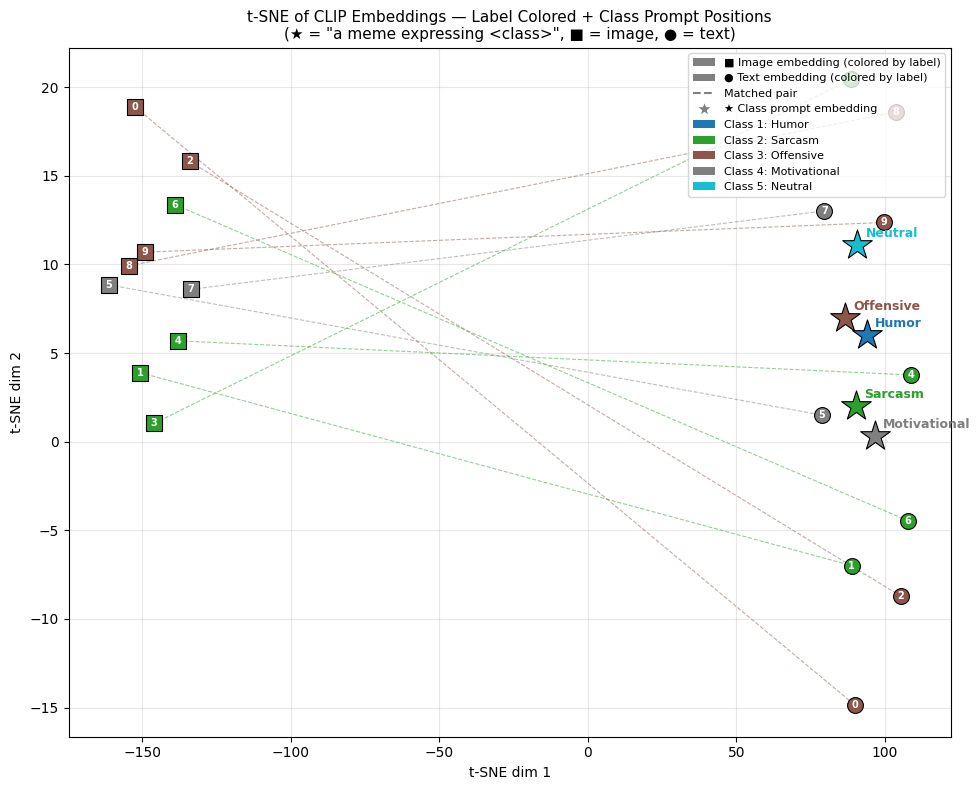

Saved: clip_tsne_enhanced.png

Nearest class prompt for each sample (cosine similarity):
Sample   True Label     Nearest Prompt    Sim
------------------------------------------------
0        Offensive      img→Humor      0.232
                        txt→Humor      0.723
1        Sarcasm        img→Motivational 0.255
                        txt→Humor      0.825
2        Offensive      img→Sarcasm    0.258
                        txt→Humor      0.870
3        Sarcasm        img→Sarcasm    0.259
                        txt→Humor      0.822
4        Sarcasm        img→Humor      0.270
                        txt→Humor      0.855
5        Motivational   img→Offensive  0.236
                        txt→Humor      0.828
6        Sarcasm        img→Motivational 0.263
                        txt→Humor      0.871
7        Motivational   img→Neutral    0.263
                        txt→Offensive  0.823
8        Offensive      img→Motivational 0.230
                        txt→Offensive  0.789


In [ ]:
# # ── Enhanced t-SNE: label coloring + class prompt embeddings ──────────────────
# # Intention classes (1-indexed in dataset, 0-indexed here)
# INTENTION_LABELS = [
#     'Humor',        # class 1
#     'Sarcasm',      # class 2
#     'Offensive',    # class 3
#     'Motivational', # class 4
#     'Neutral',      # class 5
# ]
# intention_prompts = [f'a meme expressing {lbl.lower()}' for lbl in INTENTION_LABELS]

# # Encode class prompts with CLIP
# prompt_tokens = clip.tokenize(intention_prompts, truncate=True).to(device)
# with torch.no_grad():
#     prompt_emb = clip_model.encode_text(prompt_tokens).float()  # (5, 512)
# prompt_emb = F.normalize(prompt_emb, dim=-1).cpu().numpy()

# # Stack: 10 image + 10 text + 5 class prompts = 25 points
# all_emb_ext = np.concatenate([img_emb, txt_emb, prompt_emb], axis=0)  # (25, 512)

# tsne2 = TSNE(n_components=2, perplexity=6, random_state=42, init='pca')
# emb_2d_ext = tsne2.fit_transform(all_emb_ext)  # (25, 2)

# img_2d_ext    = emb_2d_ext[:N]       # (10, 2)
# txt_2d_ext    = emb_2d_ext[N:2*N]    # (10, 2)
# prompt_2d_ext = emb_2d_ext[2*N:]     # (5, 2)

# # Color by intention label (0-4)
# label_colors = plt.cm.tab10(np.linspace(0, 1, 5))
# sample_labels = [s['intention_num'] - 1 for s in samples]  # 0-indexed

# fig, ax = plt.subplots(figsize=(10, 8))

# # ── Draw sample points colored by label ───────────────────────────────────────
# for i in range(N):
#     lc = label_colors[sample_labels[i]]
#     # Image: square
#     ax.scatter(img_2d_ext[i, 0], img_2d_ext[i, 1],
#                marker='s', s=130, color=lc, zorder=3,
#                edgecolors='black', linewidths=0.8)
#     # Text: circle
#     ax.scatter(txt_2d_ext[i, 0], txt_2d_ext[i, 1],
#                marker='o', s=130, color=lc, zorder=3,
#                edgecolors='black', linewidths=0.8)
#     # Connect matched pair
#     ax.plot([img_2d_ext[i, 0], txt_2d_ext[i, 0]],
#             [img_2d_ext[i, 1], txt_2d_ext[i, 1]],
#             color=lc, linewidth=0.8, linestyle='--', alpha=0.5, zorder=2)
#     ax.annotate(str(i), xy=(img_2d_ext[i, 0], img_2d_ext[i, 1]),
#                 fontsize=7, ha='center', va='center', color='white', fontweight='bold')
#     ax.annotate(str(i), xy=(txt_2d_ext[i, 0], txt_2d_ext[i, 1]),
#                 fontsize=7, ha='center', va='center', color='white', fontweight='bold')

# # ── Draw class prompt embeddings as large stars ────────────────────────────────
# for j, (label, pt) in enumerate(zip(INTENTION_LABELS, prompt_2d_ext)):
#     ax.scatter(pt[0], pt[1], marker='*', s=500,
#                color=label_colors[j], zorder=5,
#                edgecolors='black', linewidths=0.8)
#     ax.annotate(label, xy=(pt[0], pt[1]),
#                 xytext=(6, 6), textcoords='offset points',
#                 fontsize=9, fontweight='bold',
#                 color=label_colors[j])

# # ── Legend ────────────────────────────────────────────────────────────────────
# legend_elements = [
#     mpatches.Patch(facecolor='gray', label='■ Image embedding (colored by label)'),
#     mpatches.Patch(facecolor='gray', label='● Text embedding (colored by label)'),
#     plt.Line2D([0], [0], color='gray', linestyle='--', label='Matched pair'),
#     plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='gray',
#                markersize=12, label='★ Class prompt embedding'),
# ]
# # Add one entry per intention class
# for j, label in enumerate(INTENTION_LABELS):
#     legend_elements.append(
#         mpatches.Patch(facecolor=label_colors[j], label=f'Class {j+1}: {label}')
#     )
# ax.legend(handles=legend_elements, fontsize=8, loc='upper right', framealpha=0.8)

# ax.set_title(
#     't-SNE of CLIP Embeddings — Label Colored + Class Prompt Positions\n'
#     '(★ = "a meme expressing <class>", ■ = image, ● = text)',
#     fontsize=11
# )
# ax.set_xlabel('t-SNE dim 1')
# ax.set_ylabel('t-SNE dim 2')
# ax.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.savefig('clip_tsne_enhanced.png', dpi=150)
# plt.show()
# print('Saved: clip_tsne_enhanced.png')

# # ── Print nearest class prompt for each sample ────────────────────────────────
# print('\nNearest class prompt for each sample (cosine similarity):')
# print(f'{"Sample":<8} {"True Label":<14} {"Nearest Prompt":<14} {"Sim":>6}')
# print('-' * 48)
# for i in range(N):
#     # Compare image embedding to all class prompts
#     sims_img = img_emb[i] @ prompt_emb.T   # (5,)
#     sims_txt = txt_emb[i] @ prompt_emb.T   # (5,)
#     best_img = sims_img.argmax()
#     best_txt = sims_txt.argmax()
#     true_lbl = INTENTION_LABELS[sample_labels[i]]
#     print(f'{i:<8} {true_lbl:<14} img→{INTENTION_LABELS[best_img]:<10} {sims_img[best_img]:.3f}')
#     print(f'{"":<8} {"":<14} txt→{INTENTION_LABELS[best_txt]:<10} {sims_txt[best_txt]:.3f}')


这个图其实是不对的

## 6.3 CLIP Zero-Shot Classification (Intention & Sentiment)

Use CLIP's image encoder + text prompts to classify memes **without any training**.
For each test image, compute cosine similarity against all class prompts and take argmax.

This answers: *how much does CLIP already know about meme intention/sentiment?*  
It serves as a clean upper-bound reference — no learnable parameters involved.

**MET-Meme label definitions:**
- Intention (5 classes): Interactive, Expressive, Entertaining, Offensive, Other
- Sentiment (7 classes): Happiness, Love, Anger, Sorrow, Fear, Hate, Surprise

In [9]:
from sklearn.metrics import accuracy_score, recall_score, classification_report

# ── Label definitions (MET-Meme) ──────────────────────────────────────────────
INTENTION_LABELS = [
    'Interactive',   # intention_num = 1
    'Expressive',    # intention_num = 2
    'Entertaining',  # intention_num = 3
    'Offensive',     # intention_num = 4
    'Other',         # intention_num = 5
]
SENTIMENT_LABELS = [
    'Happiness',  # sentiment_num = 1
    'Love',       # sentiment_num = 2
    'Anger',      # sentiment_num = 3
    'Sorrow',     # sentiment_num = 4
    'Fear',       # sentiment_num = 5
    'Hate',       # sentiment_num = 6
    'Surprise',   # sentiment_num = 7
]

# Prompt templates
intention_prompts = [f'a meme that is {lbl.lower()}' for lbl in INTENTION_LABELS]
sentiment_prompts = [f'a meme expressing {lbl.lower()}' for lbl in SENTIMENT_LABELS]

# ── Sample 40 memes from test set ─────────────────────────────────────────────
N_EVAL = 40
eval_samples = [hf['test'][i] for i in range(N_EVAL)]

eval_images = torch.stack([
    clip_preprocess(s['image'].convert('RGB')) for s in eval_samples
]).to(device)  # (40, 3, 224, 224)

true_intention = [s['intention_num'] - 1 for s in eval_samples]  # 0-indexed
true_sentiment = [s['sentiment_num'] - 1 for s in eval_samples]  # 0-indexed

# ── Encode prompts ────────────────────────────────────────────────────────────
with torch.no_grad():
    img_feats = clip_model.encode_image(eval_images).float()          # (40, 512)
    img_feats = F.normalize(img_feats, dim=-1)

    int_tokens  = clip.tokenize(intention_prompts, truncate=True).to(device)
    sent_tokens = clip.tokenize(sentiment_prompts, truncate=True).to(device)
    int_feats   = F.normalize(clip_model.encode_text(int_tokens).float(),  dim=-1)  # (5, 512)
    sent_feats  = F.normalize(clip_model.encode_text(sent_tokens).float(), dim=-1)  # (7, 512)

# ── Zero-shot prediction: argmax cosine similarity ────────────────────────────
int_sims  = (img_feats @ int_feats.T).cpu().numpy()   # (40, 5)
sent_sims = (img_feats @ sent_feats.T).cpu().numpy()  # (40, 7)

pred_intention = int_sims.argmax(axis=1)
pred_sentiment = sent_sims.argmax(axis=1)

# ── Metrics ───────────────────────────────────────────────────────────────────
int_acc    = accuracy_score(true_intention, pred_intention)
int_recall = recall_score(true_intention, pred_intention, average='macro', zero_division=0)
sent_acc    = accuracy_score(true_sentiment, pred_sentiment)
sent_recall = recall_score(true_sentiment, pred_sentiment, average='macro', zero_division=0)

print('=' * 52)
print(f'CLIP Zero-Shot — Intention ({N_EVAL} test samples)')
print('=' * 52)
print(f'  Accuracy        : {int_acc*100:.1f}%')
print(f'  Macro Recall    : {int_recall*100:.1f}%')
print(f'  Random baseline : {100/len(INTENTION_LABELS):.1f}%')
print()
print(classification_report(
    true_intention, pred_intention,
    target_names=INTENTION_LABELS, zero_division=0
))

print('=' * 52)
print(f'CLIP Zero-Shot — Sentiment ({N_EVAL} test samples)')
print('=' * 52)
print(f'  Accuracy        : {sent_acc*100:.1f}%')
print(f'  Macro Recall    : {sent_recall*100:.1f}%')
print(f'  Random baseline : {100/len(SENTIMENT_LABELS):.1f}%')
print()
print(classification_report(
    true_sentiment, pred_sentiment,
    target_names=SENTIMENT_LABELS, zero_division=0
))


CLIP Zero-Shot — Intention (40 test samples)
  Accuracy        : 32.5%
  Macro Recall    : 20.3%
  Random baseline : 20.0%

              precision    recall  f1-score   support

 Interactive       0.00      0.00      0.00         3
  Expressive       0.53      0.45      0.49        20
Entertaining       0.33      0.17      0.22        12
   Offensive       0.67      0.40      0.50         5
       Other       0.00      0.00      0.00         0

    accuracy                           0.33        40
   macro avg       0.31      0.20      0.24        40
weighted avg       0.45      0.33      0.37        40

CLIP Zero-Shot — Sentiment (40 test samples)
  Accuracy        : 32.5%
  Macro Recall    : 18.7%
  Random baseline : 14.3%

              precision    recall  f1-score   support

   Happiness       0.17      0.25      0.20         4
        Love       0.75      0.41      0.53        22
       Anger       0.00      0.00      0.00         2
      Sorrow       0.25      0.40      0.31   

## 6.4 CLIP Concat Baseline

Direct concatenation of raw CLIP embeddings → linear classifier, **no projection, no incongruity module**.

This is the ablation baseline for Section 7:  
- If concat(512+512)→Linear already performs well, the added complexity of Section 7 is not justified
- If Section 7 outperforms this, it shows the incongruity module adds value beyond raw alignment

In [37]:
# ── CLIP Encoders ─────────────────────────────────────────────────────────────
# clip_model and clip_preprocess are already loaded from Section 6.

class CLIPImageEncoder(nn.Module):
    """Frozen CLIP ViT-B/32 image tower + trainable projection to output_dim."""
    def __init__(self, output_dim=64):
        super().__init__()
        self.clip = clip_model.visual
        for p in self.clip.parameters():
            p.requires_grad = False
        self.proj = nn.Linear(512, output_dim)

    def forward(self, x):
        # x: (batch, 3, 224, 224) preprocessed by clip_preprocess
        with torch.no_grad():
            feat = clip_model.encode_image(x).float()  # (batch, 512)
            feat = F.normalize(feat, dim=-1)
        return self.proj(feat)                          # (batch, output_dim)


class CLIPTextEncoder(nn.Module):
    """Frozen CLIP ViT-B/32 text tower + trainable projection to output_dim."""
    def __init__(self, output_dim=64):
        super().__init__()
        for p in clip_model.parameters():
            p.requires_grad = False
        self.proj = nn.Linear(512, output_dim)

    def forward(self, x):
        # x: (batch, 77) token ids from clip.tokenize
        with torch.no_grad():
            feat = clip_model.encode_text(x.long()).float()   # 加 .long()
            feat = F.normalize(feat, dim=-1)
        return self.proj(feat)


print('CLIPImageEncoder and CLIPTextEncoder defined.')

CLIPImageEncoder and CLIPTextEncoder defined.


In [38]:
# ── CLIP Dataset ──────────────────────────────────────────────────────────────
# CLIP requires its own preprocessing (clip_preprocess) and tokenization.

class CLIPDataset(Dataset):
    def __init__(self, hf_split):
        self.data = hf_split

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row   = self.data[idx]
        image = clip_preprocess(row['image'].convert('RGB'))  # (3, 224, 224)
        # clip.tokenize returns (1, 77); squeeze to (77,)
        text  = clip.tokenize([row['caption']], truncate=True).squeeze(0)  # (77,)
        label = row['intention_num'] - 1
        return image, text, label


clip_trainset = CLIPDataset(hf['train'])
clip_valset   = CLIPDataset(hf['validation'])
clip_testset  = CLIPDataset(hf['test'])

clip_traindata = DataLoader(clip_trainset, batch_size=64, shuffle=True)
clip_valdata   = DataLoader(clip_valset,   batch_size=64)
clip_testdata  = DataLoader(clip_testset,  batch_size=64)

print(f'CLIP datasets ready — Train: {len(clip_trainset)}, Val: {len(clip_valset)}, Test: {len(clip_testset)}')

NameError: name 'hf' is not defined

In [30]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
CONCAT_EPOCHS      = 10
CONCAT_LR          = 5e-4
CONCAT_WEIGHT_DECAY= 1e-3
CONCAT_BATCH_SIZE  = 64

# ── Paths ─────────────────────────────────────────────────────────────────────
os.makedirs('artifacts', exist_ok=True)
CONCAT_CKPT    = 'artifacts/clip_concat_best.pt'
CONCAT_HISTORY = 'artifacts/clip_concat_history.npy'
CONCAT_EMB     = 'artifacts/clip_concat_emb.npz'

# ── Model ─────────────────────────────────────────────────────────────────────
class CLIPConcatClassifier(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.head = nn.Linear(1024, num_classes)

    def forward(self, img_feat, txt_feat):
        return self.head(torch.cat([img_feat, txt_feat], dim=-1))


# ── Pre-cache CLIP embeddings (skip if already saved) ─────────────────────────
def cache_clip_embeddings(hf_split):
    all_img, all_txt, all_lbl = [], [], []
    loader = DataLoader(CLIPDataset(hf_split), batch_size=CONCAT_BATCH_SIZE, shuffle=False)
    clip_model.eval()
    with torch.no_grad():
        for imgs, texts, labels in loader:
            imgs, texts = imgs.to(device), texts.to(device)
            i_feat = F.normalize(clip_model.encode_image(imgs).float(), dim=-1).cpu()
            t_feat = F.normalize(clip_model.encode_text(texts).float(), dim=-1).cpu()
            all_img.append(i_feat); all_txt.append(t_feat); all_lbl.append(labels)
    return torch.cat(all_img), torch.cat(all_txt), torch.cat(all_lbl)

if os.path.exists(CONCAT_EMB):
    print('Loading cached CLIP embeddings...')
    data = np.load(CONCAT_EMB)
    tr_img = torch.from_numpy(data['tr_img']); tr_txt = torch.from_numpy(data['tr_txt']); tr_lbl = torch.from_numpy(data['tr_lbl'])
    va_img = torch.from_numpy(data['va_img']); va_txt = torch.from_numpy(data['va_txt']); va_lbl = torch.from_numpy(data['va_lbl'])
    te_img = torch.from_numpy(data['te_img']); te_txt = torch.from_numpy(data['te_txt']); te_lbl = torch.from_numpy(data['te_lbl'])
else:
    print('Caching CLIP embeddings for all splits...')
    tr_img, tr_txt, tr_lbl = cache_clip_embeddings(hf['train'])
    va_img, va_txt, va_lbl = cache_clip_embeddings(hf['validation'])
    te_img, te_txt, te_lbl = cache_clip_embeddings(hf['test'])
    np.savez(CONCAT_EMB,
             tr_img=tr_img.numpy(), tr_txt=tr_txt.numpy(), tr_lbl=tr_lbl.numpy(),
             va_img=va_img.numpy(), va_txt=va_txt.numpy(), va_lbl=va_lbl.numpy(),
             te_img=te_img.numpy(), te_txt=te_txt.numpy(), te_lbl=te_lbl.numpy())
    print(f'Saved to {CONCAT_EMB}')

from torch.utils.data import TensorDataset
tr_loader = DataLoader(TensorDataset(tr_img, tr_txt, tr_lbl), batch_size=CONCAT_BATCH_SIZE, shuffle=True)
va_loader = DataLoader(TensorDataset(va_img, va_txt, va_lbl), batch_size=CONCAT_BATCH_SIZE)
te_loader = DataLoader(TensorDataset(te_img, te_txt, te_lbl), batch_size=CONCAT_BATCH_SIZE)

# ── Train or load checkpoint ───────────────────────────────────────────────────
concat_model = CLIPConcatClassifier(num_classes=num_classes).to(device)

if os.path.exists(CONCAT_CKPT) and os.path.exists(CONCAT_HISTORY):
    print(f'Loading checkpoint from {CONCAT_CKPT}...')
    concat_model.load_state_dict(torch.load(CONCAT_CKPT, map_location=device))
    history = np.load(CONCAT_HISTORY, allow_pickle=True).item()
    print(f'Loaded. Best val acc: {max(history["val_acc"])*100:.2f}%')
else:
    optimizer = torch.optim.AdamW(concat_model.parameters(), lr=CONCAT_LR, weight_decay=CONCAT_WEIGHT_DECAY)
    history   = {'train_loss': [], 'val_acc': []}
    best_val_acc, best_state = 0.0, None

    for epoch in range(CONCAT_EPOCHS):
        concat_model.train()
        epoch_loss = 0.0
        for img_f, txt_f, lbl in tr_loader:
            img_f, txt_f, lbl = img_f.to(device), txt_f.to(device), lbl.long().to(device)
            optimizer.zero_grad()
            loss = nn.CrossEntropyLoss()(concat_model(img_f, txt_f), lbl)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        history['train_loss'].append(epoch_loss / len(tr_loader))

        concat_model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for img_f, txt_f, lbl in va_loader:
                img_f, txt_f, lbl = img_f.to(device), txt_f.to(device), lbl.long().to(device)
                correct += (concat_model(img_f, txt_f).argmax(1) == lbl).sum().item()
                total   += lbl.size(0)
        val_acc = correct / total
        history['val_acc'].append(val_acc)
        print(f'  Epoch {epoch+1:02d} — train loss: {history["train_loss"][-1]:.4f}  val acc: {val_acc:.4f}')
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = {k: v.clone() for k, v in concat_model.state_dict().items()}

    concat_model.load_state_dict(best_state)
    torch.save(best_state, CONCAT_CKPT)
    np.save(CONCAT_HISTORY, history)
    print(f'Saved checkpoint → {CONCAT_CKPT}')
    print(f'Saved history    → {CONCAT_HISTORY}')

# ── Test evaluation ───────────────────────────────────────────────────────────
concat_model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for img_f, txt_f, lbl in te_loader:
        img_f, txt_f = img_f.to(device), txt_f.to(device)
        all_preds.append(concat_model(img_f, txt_f).argmax(1).cpu())
        all_true.append(lbl)
all_preds = torch.cat(all_preds).numpy()
all_true  = torch.cat(all_true).numpy()

concat_acc    = accuracy_score(all_true, all_preds)
concat_recall = recall_score(all_true, all_preds, average='macro',
zero_division=0)
print(f'\nCLIP Concat Baseline — Test Accuracy : {concat_acc*100:.2f}%')
print(f'CLIP Concat Baseline — Macro Recall  : {concat_recall*100:.2f}%')
print()
print(classification_report(all_true, all_preds,
                            labels=list(range(len(INTENTION_LABELS))),
                            target_names=INTENTION_LABELS,
                            zero_division=0))


Loading cached CLIP embeddings...
Loading checkpoint from artifacts/clip_concat_best.pt...
Loaded. Best val acc: 40.24%

CLIP Concat Baseline — Test Accuracy : 42.35%
CLIP Concat Baseline — Macro Recall  : 27.36%

              precision    recall  f1-score   support

 Interactive       0.00      0.00      0.00        37
  Expressive       0.41      0.57      0.48       112
Entertaining       0.43      0.52      0.47       153
   Offensive       0.00      0.00      0.00        38
       Other       0.00      0.00      0.00         0

    accuracy                           0.42       340
   macro avg       0.17      0.22      0.19       340
weighted avg       0.33      0.42      0.37       340



In [31]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
CONCAT_EPOCHS      = 10
CONCAT_LR          = 5e-4
CONCAT_WEIGHT_DECAY= 1e-3
CONCAT_BATCH_SIZE  = 64

# ── Paths ─────────────────────────────────────────────────────────────────────
os.makedirs('artifacts', exist_ok=True)
CONCAT_CKPT    = 'artifacts/clip_concat_weighted_best.pt'
CONCAT_HISTORY = 'artifacts/clip_concat_weighted_history.npy'
CONCAT_EMB     = 'artifacts/clip_concat_emb.npz'  # embeddings 不变，可复用

# ── Model ─────────────────────────────────────────────────────────────────────
class CLIPConcatClassifier(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.head = nn.Linear(1024, num_classes)

    def forward(self, img_feat, txt_feat):
        return self.head(torch.cat([img_feat, txt_feat], dim=-1))


# ── Pre-cache CLIP embeddings (skip if already saved) ─────────────────────────
def cache_clip_embeddings(hf_split):
    all_img, all_txt, all_lbl = [], [], []
    loader = DataLoader(CLIPDataset(hf_split), batch_size=CONCAT_BATCH_SIZE, shuffle=False)
    clip_model.eval()
    with torch.no_grad():
        for imgs, texts, labels in loader:
            imgs, texts = imgs.to(device), texts.to(device)
            i_feat = F.normalize(clip_model.encode_image(imgs).float(), dim=-1).cpu()
            t_feat = F.normalize(clip_model.encode_text(texts).float(), dim=-1).cpu()
            all_img.append(i_feat); all_txt.append(t_feat); all_lbl.append(labels)
    return torch.cat(all_img), torch.cat(all_txt), torch.cat(all_lbl)

if os.path.exists(CONCAT_EMB):
    print('Loading cached CLIP embeddings...')
    data = np.load(CONCAT_EMB)
    tr_img = torch.from_numpy(data['tr_img']); tr_txt = torch.from_numpy(data['tr_txt']); tr_lbl = torch.from_numpy(data['tr_lbl'])
    va_img = torch.from_numpy(data['va_img']); va_txt = torch.from_numpy(data['va_txt']); va_lbl = torch.from_numpy(data['va_lbl'])
    te_img = torch.from_numpy(data['te_img']); te_txt = torch.from_numpy(data['te_txt']); te_lbl = torch.from_numpy(data['te_lbl'])
else:
    print('Caching CLIP embeddings for all splits...')
    tr_img, tr_txt, tr_lbl = cache_clip_embeddings(hf['train'])
    va_img, va_txt, va_lbl = cache_clip_embeddings(hf['validation'])
    te_img, te_txt, te_lbl = cache_clip_embeddings(hf['test'])
    np.savez(CONCAT_EMB,
             tr_img=tr_img.numpy(), tr_txt=tr_txt.numpy(), tr_lbl=tr_lbl.numpy(),
             va_img=va_img.numpy(), va_txt=va_txt.numpy(), va_lbl=va_lbl.numpy(),
             te_img=te_img.numpy(), te_txt=te_txt.numpy(), te_lbl=te_lbl.numpy())
    print(f'Saved to {CONCAT_EMB}')

from torch.utils.data import TensorDataset
tr_loader = DataLoader(TensorDataset(tr_img, tr_txt, tr_lbl), batch_size=CONCAT_BATCH_SIZE, shuffle=True)
va_loader = DataLoader(TensorDataset(va_img, va_txt, va_lbl), batch_size=CONCAT_BATCH_SIZE)
te_loader = DataLoader(TensorDataset(te_img, te_txt, te_lbl), batch_size=CONCAT_BATCH_SIZE)

# ── Train or load checkpoint ───────────────────────────────────────────────────
concat_model = CLIPConcatClassifier(num_classes=num_classes).to(device)

if os.path.exists(CONCAT_CKPT) and os.path.exists(CONCAT_HISTORY):
    print(f'Loading checkpoint from {CONCAT_CKPT}...')
    concat_model.load_state_dict(torch.load(CONCAT_CKPT, map_location=device))
    history = np.load(CONCAT_HISTORY, allow_pickle=True).item()
    print(f'Loaded. Best val acc: {max(history["val_acc"])*100:.2f}%')
else:
  # added
    class_counts = torch.bincount(tr_lbl.long(), minlength=num_classes).float()
    class_weights = (1.0 / class_counts.clamp(min=1)).to(device)
    class_weights = class_weights / class_weights.sum() * num_classes
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    # end added
    optimizer = torch.optim.AdamW(concat_model.parameters(), lr=CONCAT_LR, weight_decay=CONCAT_WEIGHT_DECAY)
    history   = {'train_loss': [], 'val_acc': []}
    best_val_acc, best_state = 0.0, None

    for epoch in range(CONCAT_EPOCHS):
        concat_model.train()
        epoch_loss = 0.0
        for img_f, txt_f, lbl in tr_loader:
            img_f, txt_f, lbl = img_f.to(device), txt_f.to(device), lbl.long().to(device)
            optimizer.zero_grad()
            # loss = nn.CrossEntropyLoss()(concat_model(img_f, txt_f), lbl)
            loss = criterion(concat_model(img_f, txt_f), lbl) # revised
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        history['train_loss'].append(epoch_loss / len(tr_loader))

        concat_model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for img_f, txt_f, lbl in va_loader:
                img_f, txt_f, lbl = img_f.to(device), txt_f.to(device), lbl.long().to(device)
                correct += (concat_model(img_f, txt_f).argmax(1) == lbl).sum().item()
                total   += lbl.size(0)
        val_acc = correct / total
        history['val_acc'].append(val_acc)
        print(f'  Epoch {epoch+1:02d} — train loss: {history["train_loss"][-1]:.4f}  val acc: {val_acc:.4f}')
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = {k: v.clone() for k, v in concat_model.state_dict().items()}

    concat_model.load_state_dict(best_state)
    torch.save(best_state, CONCAT_CKPT)
    np.save(CONCAT_HISTORY, history)
    print(f'Saved checkpoint → {CONCAT_CKPT}')
    print(f'Saved history    → {CONCAT_HISTORY}')

# ── Test evaluation ───────────────────────────────────────────────────────────
concat_model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for img_f, txt_f, lbl in te_loader:
        img_f, txt_f = img_f.to(device), txt_f.to(device)
        all_preds.append(concat_model(img_f, txt_f).argmax(1).cpu())
        all_true.append(lbl)
all_preds = torch.cat(all_preds).numpy()
all_true  = torch.cat(all_true).numpy()

concat_acc    = accuracy_score(all_true, all_preds)
concat_recall = recall_score(all_true, all_preds, average='macro',
zero_division=0)
print(f'\nCLIP Concat Baseline — Test Accuracy : {concat_acc*100:.2f}%')
print(f'CLIP Concat Baseline — Macro Recall  : {concat_recall*100:.2f}%')
print()
print(classification_report(all_true, all_preds,
                            labels=list(range(len(INTENTION_LABELS))),
                            target_names=INTENTION_LABELS,
                            zero_division=0))


Loading cached CLIP embeddings...
Loading checkpoint from artifacts/clip_concat_weighted_best.pt...
Loaded. Best val acc: 39.35%

CLIP Concat Baseline — Test Accuracy : 39.71%
CLIP Concat Baseline — Macro Recall  : 31.09%

              precision    recall  f1-score   support

 Interactive       0.00      0.00      0.00        37
  Expressive       0.41      0.54      0.46       112
Entertaining       0.45      0.42      0.43       153
   Offensive       0.24      0.29      0.26        38
       Other       0.00      0.00      0.00         0

    accuracy                           0.40       340
   macro avg       0.22      0.25      0.23       340
weighted avg       0.36      0.40      0.38       340



## 7. CLIP-based Sentiment-Incongruity-Aware Fusion

The ResNet+BERT fusion failed because the two encoder spaces are completely unaligned —
fusion operates on meaningless vector combinations.

CLIP (ViT-B/32) jointly trains image and text encoders with a contrastive objective,
so their 512-dim outputs **live in the same semantic space** and are directly comparable.

We reuse `SentimentIncongruityFusion` unchanged, replacing only the encoders:
- `CLIPImageEncoder`: frozen ViT-B/32 image tower + trainable Linear(512→64)
- `CLIPTextEncoder`: frozen ViT-B/32 text tower + trainable Linear(512→64)

Everything else (fusion module, MLP head, training loop) stays identical for a fair comparison.

In [34]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
CLIP_INCONG_EPOCHS       = 10
CLIP_INCONG_LR           = 5e-4
CLIP_INCONG_WEIGHT_DECAY = 1e-3

# ── Paths ─────────────────────────────────────────────────────────────────────
CLIP_INCONG_CKPT = 'artifacts/clip_incong_fusion.pt'

# ── Train or load ─────────────────────────────────────────────────────────────
if os.path.exists(CLIP_INCONG_CKPT):
    print(f'Checkpoint found. Loading from {CLIP_INCONG_CKPT}...')
    clip_incong_model = torch.load(CLIP_INCONG_CKPT, map_location=device).to(device)
    print('Loaded. Skipping training.')
else:
    clip_fusion   = SentimentIncongruityFusion(input_dim=64, num_sentiments=num_classes)
    clip_head     = MLP(69, 256, num_classes)
    clip_encoders = [CLIPImageEncoder(output_dim=64), CLIPTextEncoder(output_dim=64)]

    print('Training CLIP-based Sentiment-Incongruity-Aware Fusion...')
    train(
        clip_encoders, clip_fusion, clip_head,
        clip_traindata, clip_valdata,
        total_epochs=CLIP_INCONG_EPOCHS,
        task='classification',
        optimtype=torch.optim.AdamW,
        is_packed=False,
        lr=CLIP_INCONG_LR,
        save=CLIP_INCONG_CKPT,
        weight_decay=CLIP_INCONG_WEIGHT_DECAY,
        objective=torch.nn.CrossEntropyLoss(),
        input_to_float=False
    )
    clip_incong_model = torch.load(CLIP_INCONG_CKPT, map_location=device).to(device)

print('\n--- CLIP Fusion Test Results ---')
test(
    clip_incong_model, clip_testdata,
    is_packed=False,
    task='classification',
    criterion=torch.nn.CrossEntropyLoss(),
    no_robust=True
)


Checkpoint found. Loading from artifacts/clip_incong_fusion.pt...
Loaded. Skipping training.

--- CLIP Fusion Test Results ---
acc: 0.45
Inference Time: 1.2367734909057617
Inference Params: 87934864


In [36]:
# ── Evaluate CLIP Fusion ──────────────────────────────────────────────────────
clip_incong_model.eval()
correct_clip, total_clip = 0, 0
with torch.no_grad():
    for imgs, text, label in clip_testdata:
        imgs  = imgs.to(device)
        text  = text.to(device)
        label = label.long().to(device)
        out   = clip_incong_model([imgs, text])
        correct_clip += (out.argmax(1) == label).sum().item()
        total_clip   += label.size(0)

clip_test_acc = 100 * correct_clip / total_clip
print(f'CLIP Fusion Test Accuracy: {clip_test_acc:.2f}%')

clip_full = MMDL(
    [CLIPImageEncoder(output_dim=64), CLIPTextEncoder(output_dim=64)],
    SentimentIncongruityFusion(input_dim=64, num_sentiments=num_classes),
    MLP(69, 256, num_classes)
)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'CLIP Fusion trainable parameters: {count_params(clip_incong_model):,}')

CLIP Fusion Test Accuracy: 45.00%
CLIP Fusion trainable parameters: 85,648


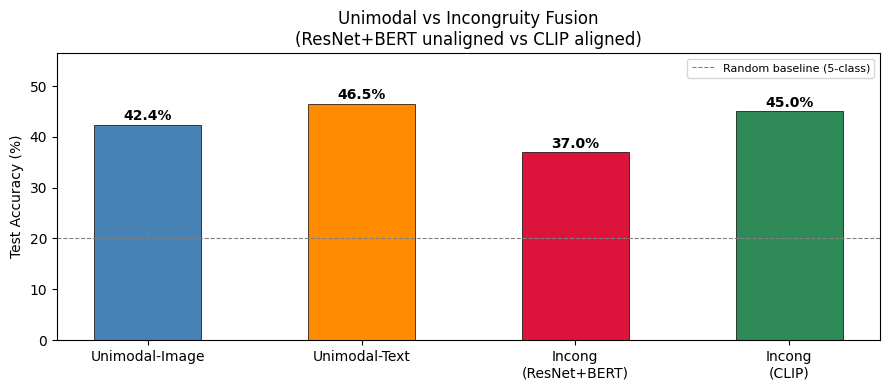

Saved: clip_vs_resnet_fusion.png

CLIP fusion vs ResNet+BERT fusion: +8.02% (positive = CLIP better)


In [37]:
# ── Full Comparison Chart ─────────────────────────────────────────────────────
all_results_clip = {
    **unimodal_results,                            # Unimodal-Image, Unimodal-Text
    'Incong\n(ResNet+BERT)': 100 * correct / total,  # from Section 5
    'Incong\n(CLIP)': clip_test_acc,
}

names  = list(all_results_clip.keys())
accs   = [all_results_clip[n] for n in names]
colors = ['steelblue', 'darkorange', 'crimson', 'seagreen']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(names, accs, color=colors, width=0.5, edgecolor='black', linewidth=0.5)

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Unimodal vs Incongruity Fusion\n(ResNet+BERT unaligned vs CLIP aligned)')
ax.set_ylim(0, max(accs) + 10)
ax.axhline(y=20, color='gray', linestyle='--', linewidth=0.8, label='Random baseline (5-class)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('clip_vs_resnet_fusion.png', dpi=150)
plt.show()
print('Saved: clip_vs_resnet_fusion.png')

# Print delta
delta = clip_test_acc - (100 * correct / total)
print(f'\nCLIP fusion vs ResNet+BERT fusion: {delta:+.2f}% (positive = CLIP better)')

---
## 8. Inference on `meme_sample` — Sentiment Distributions & Incongruity Score

No training required. We use:
- **CLIP ViT-B/32** (zero-shot) to map each image into a 9-sentiment probability distribution via cosine similarity with sentiment prompts
- **EasyOCR** to extract text from each meme image, then CLIP text encoder to map OCR text into the same sentiment space
- **Incongruity score** = mean absolute difference between image-sentiment and text-sentiment distributions (∈ [0, 1])

This is a fully inference-only pipeline — no weights are loaded or trained.

In [21]:
# ── Install (run once) ────────────────────────────────────────────────────────
!pip install -q easyocr
!pip install -q git+https://github.com/openai/CLIP.git

import os, glob, textwrap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn.functional as F
from PIL import Image
import clip
import easyocr

# ── Paths ─────────────────────────────────────────────────────────────────────
MEME_DIR = '../../data/meme_sample'
IMG_EXTS  = ('*.png', '*.jpg', '*.jpeg', '*.webp', '*.gif')
img_paths = sorted(p for ext in IMG_EXTS for p in glob.glob(os.path.join(MEME_DIR, ext)))
print(f'Found {len(img_paths)} images:')
for p in img_paths:
    print(f'  {os.path.basename(p)}')

# ── Load CLIP ─────────────────────────────────────────────────────────────────
device = 'cuda' if torch.cuda.is_available() else 'cpu'
clip_model, clip_preprocess = clip.load('ViT-B/32', device=device)
clip_model.eval()
print(f'CLIP loaded on {device}')

# ── Load EasyOCR ──────────────────────────────────────────────────────────────
ocr_reader = easyocr.Reader(['en', 'ch_sim'], gpu=torch.cuda.is_available())
print('EasyOCR ready')

objc[20484]: Class AVFFrameReceiver is implemented in both /opt/miniconda3/envs/mmai/lib/python3.10/site-packages/av/.dylibs/libavdevice.62.1.100.dylib (0x106cec3a8) and /opt/miniconda3/envs/mmai/lib/python3.10/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x1650f83a8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[20484]: Class AVFAudioReceiver is implemented in both /opt/miniconda3/envs/mmai/lib/python3.10/site-packages/av/.dylibs/libavdevice.62.1.100.dylib (0x106cec3f8) and /opt/miniconda3/envs/mmai/lib/python3.10/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x1650f83f8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.


Found 10 images:
  1268.webp
  Meme-Famous_Man_Uses_Notoriety_To_Raise_Funds_for_Multiple_Sclerosis-532aa03e3c46107a9342c7f1aad2a4a0.webp
  Screen Shot 2019-03-14 at 10.53.38 AM.webp
  images.jpeg
  sub-buzz-28390-1548266319-1.webp
  sub-buzz-31148-1548266852-1.webp
  wechat_memesample_1.png
  wechat_memesample_2.png
  wechat_memesample_3.png
  wechat_memesample_4.png


Using CPU. Note: This module is much faster with a GPU.


CLIP loaded on cpu
EasyOCR ready


In [22]:
# ── Sentiment prompt space (9 dimensions) ────────────────────────────────────
SENTIMENTS = [
    'happiness', 'love', 'anger', 'sadness',
    'fear', 'disgust', 'surprise', 'sarcasm', 'neutral'
]

# Visually descriptive prompts — CLIP responds better to concrete visual cues
# than abstract emotion words. Multiple diverse prompts per sentiment.
SENTIMENT_PROMPTS = {
    'happiness': [
        'a person laughing and smiling with joy',
        'a cheerful and happy scene with bright colors',
        'people celebrating and having fun',
    ],
    'love': [
        'a romantic and affectionate scene',
        'people hugging or showing warmth and care',
        'a wholesome and heartwarming image',
    ],
    'anger': [
        'an angry person yelling or looking furious',
        'a scene of conflict rage and frustration',
        'someone looking mad with clenched fists',
    ],
    'sadness': [
        'a sad person crying with tears',
        'a gloomy depressing and melancholic scene',
        'someone looking miserable and heartbroken',
    ],
    'fear': [
        'a scared person looking terrified and anxious',
        'a frightening and horrifying scene',
        'someone trembling with wide eyes in fear',
    ],
    'disgust': [
        'a disgusting and revolting scene',
        'someone looking grossed out with a disgusted face',
        'an unpleasant and repulsive image',
    ],
    'surprise': [
        'a shocked person with mouth wide open',
        'an unexpected and astonishing scene',
        'someone looking amazed with wide eyes',
    ],
    'sarcasm': [
        'a sarcastic meme with ironic meaning',
        'an image where the visual contradicts the expected meaning',
        'a cynical and mocking scene with hidden irony',
    ],
    'neutral': [
        'a neutral and emotionless everyday scene',
        'a plain ordinary image with no strong emotion',
        'a calm and uneventful situation',
    ],
}

with torch.no_grad():
    sent_vecs = []
    for s in SENTIMENTS:
        tokens = clip.tokenize(SENTIMENT_PROMPTS[s], truncate=True).to(device)
        embs   = clip_model.encode_text(tokens).float()
        embs   = F.normalize(embs, dim=-1)
        sent_vecs.append(embs.mean(0))      # average all prompts for this sentiment
    sent_matrix = torch.stack(sent_vecs)    # (9, 512)
    sent_matrix = F.normalize(sent_matrix, dim=-1)

# Print pairwise cosine sim to verify prompts are discriminative
print('Sentiment prompt matrix shape:', sent_matrix.shape)
print('\nInter-sentiment cosine similarities (lower = more discriminative):')
sim_mat = (sent_matrix @ sent_matrix.T).cpu().numpy()
import numpy as _np
for i, s in enumerate(SENTIMENTS):
    sims = [f'{sim_mat[i,j]:.3f}' for j in range(len(SENTIMENTS))]
    print(f'  {s:<12}: {" ".join(sims)}')
off_diag = sim_mat[_np.triu_indices(len(SENTIMENTS), k=1)]
print(f'\nMean off-diagonal sim: {off_diag.mean():.4f} (lower = better separation)')


Sentiment prompt matrix shape: torch.Size([9, 512])

Inter-sentiment cosine similarities (lower = more discriminative):
  happiness   : 1.000 0.912 0.882 0.855 0.884 0.891 0.897 0.891 0.890
  love        : 0.912 1.000 0.882 0.905 0.905 0.917 0.905 0.928 0.924
  anger       : 0.882 0.882 1.000 0.914 0.943 0.941 0.941 0.915 0.916
  sadness     : 0.855 0.905 0.914 1.000 0.935 0.937 0.921 0.921 0.934
  fear        : 0.884 0.905 0.943 0.935 1.000 0.967 0.971 0.941 0.942
  disgust     : 0.891 0.917 0.941 0.937 0.967 1.000 0.956 0.957 0.948
  surprise    : 0.897 0.905 0.941 0.921 0.971 0.956 1.000 0.934 0.924
  sarcasm     : 0.891 0.928 0.915 0.921 0.941 0.957 0.934 1.000 0.962
  neutral     : 0.890 0.924 0.916 0.934 0.942 0.948 0.924 0.962 1.000

Mean off-diagonal sim: 0.9220 (lower = better separation)


In [26]:
# ── Per-image inference: OCR + sentiment distributions ───────────────────────
def get_image_sentiment(img: Image.Image) -> np.ndarray:
    """CLIP image → cosine sim against sentiment prompts → softmax probs."""
    x = clip_preprocess(img).unsqueeze(0).to(device)
    with torch.no_grad():
        img_emb = clip_model.encode_image(x).float()
        img_emb = F.normalize(img_emb, dim=-1)
        sims    = (img_emb @ sent_matrix.T).squeeze(0)   # (9,)
        probs   = F.softmax(sims * 100, dim=0)            # temperature=100: sharpen distribution
    return probs.cpu().numpy()


def get_text_sentiment(text: str) -> np.ndarray | None:
    """CLIP text → cosine sim against sentiment prompts → softmax probs."""
    if not text.strip():
        return None
    tokens = clip.tokenize([text], truncate=True).to(device)
    with torch.no_grad():
        txt_emb = clip_model.encode_text(tokens).float()
        txt_emb = F.normalize(txt_emb, dim=-1)
        sims    = (txt_emb @ sent_matrix.T).squeeze(0)   # (9,)
        probs   = F.softmax(sims * 100, dim=0)
    return probs.cpu().numpy()


def ocr_image(img: Image.Image) -> str:
    """Run EasyOCR on a PIL image and return concatenated text."""
    results = ocr_reader.readtext(np.array(img), detail=0)
    return ' '.join(results).strip()


def translate_to_english(text: str) -> str:
    """Translate text to English using GPT if it contains non-ASCII characters."""
    if not text.strip():
        return text
    # Check if text contains non-ASCII (likely Chinese/non-English)
    if all(ord(c) < 128 for c in text):
        return text  # already ASCII, skip translation
    try:
        from openai import OpenAI as _OpenAI
        import os as _os
        _client = _OpenAI(api_key=_os.environ['OPENAI_API_KEY'])
        resp = _client.chat.completions.create(
            model='gpt-4o-mini',
            messages=[{
                'role': 'user',
                'content': f'Translate the following text to English. Return only the translation, no explanation:\n{text}'
            }],
            max_tokens=200,
            temperature=0,
        )
        return resp.choices[0].message.content.strip()
    except Exception as e:
        print(f'  [translate error] {e}')
        return text  # fallback: use original


# ── Run on all images ─────────────────────────────────────────────────────────
records = []
for path in img_paths:
    img  = Image.open(path).convert('RGB')
    name = os.path.basename(path)

    img_sent  = get_image_sentiment(img)
    ocr_text  = ocr_image(img)
    ocr_en    = translate_to_english(ocr_text)  # translate to English for CLIP
    txt_sent  = get_text_sentiment(ocr_en)

    # Incongruity score: mean |img_sent - txt_sent|, 0 if no text detected
    if txt_sent is not None:
        incong_score = float(np.abs(img_sent - txt_sent).mean())
    else:
        incong_score = 0.0

    records.append({
        'name':        name,
        'path':        path,
        'img':         img,
        'ocr_text':    ocr_text,
        'ocr_en':      ocr_en,
        'img_sent':    img_sent,
        'txt_sent':    txt_sent,
        'incong_score':incong_score,
    })
    print(f'[{name}]')
    print(f'  OCR (orig) : {ocr_text[:80] if ocr_text else "(none)"}')
    if ocr_en != ocr_text:
        print(f'  OCR (en)   : {ocr_en[:80]}')
    print(f'  Score      : {incong_score:.4f}')
    print()

[1268.webp]
  OCR (orig) : (none)
  Score      : 0.0000

[Meme-Famous_Man_Uses_Notoriety_To_Raise_Funds_for_Multiple_Sclerosis-532aa03e3c46107a9342c7f1aad2a4a0.webp]
  OCR (orig) : (none)
  Score      : 0.0000

[Screen Shot 2019-03-14 at 10.53.38 AM.webp]
  OCR (orig) : Going to Work Going to work to pick 叩 my paycheck
  OCR (en)   : Going to work to pick up my paycheck.
  Score      : 0.0415

[images.jpeg]
  OCR (orig) : (none)
  Score      : 0.0000

[sub-buzz-28390-1548266319-1.webp]
  OCR (orig) : (none)
  Score      : 0.0000

[sub-buzz-31148-1548266852-1.webp]
  OCR (orig) : 04
  Score      : 0.0667

[wechat_memesample_1.png]
  OCR (orig) : 公主专用跑车 来啦
  OCR (en)   : The princess's exclusive sports car is here!
  Score      : 0.0821

[wechat_memesample_2.png]
  OCR (orig) : (none)
  Score      : 0.0000

[wechat_memesample_3.png]
  OCR (orig) : 爸呀 大哥
  OCR (en)   : Dad, big brother.
  Score      : 0.0976

[wechat_memesample_4.png]
  OCR (orig) : EARD
  Score      : 0.1578



/var/folders/dl/qk95d0zj23j9sjmtb6_4gh_w0000gn/T/ipykernel_20484/62588440.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


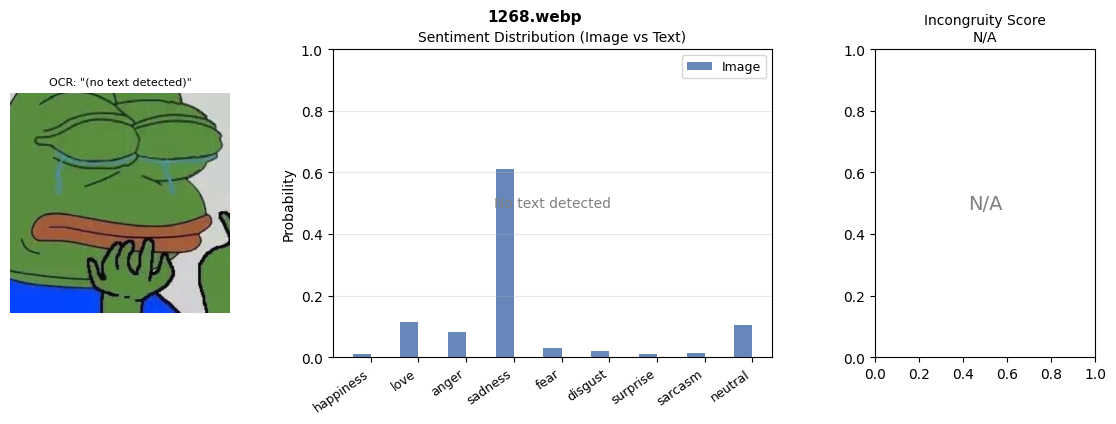

/var/folders/dl/qk95d0zj23j9sjmtb6_4gh_w0000gn/T/ipykernel_20484/62588440.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


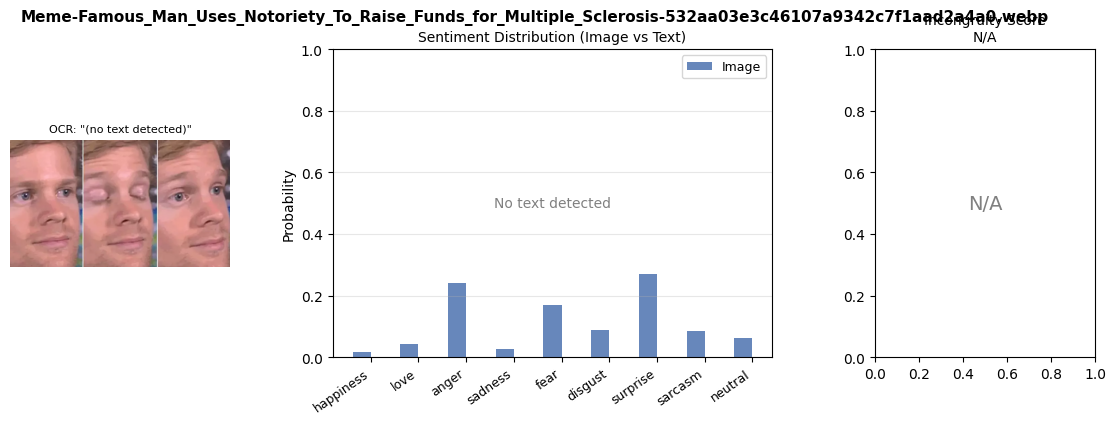

/var/folders/dl/qk95d0zj23j9sjmtb6_4gh_w0000gn/T/ipykernel_20484/62588440.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/opt/miniconda3/envs/mmai/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21481 (\N{CJK UNIFIED IDEOGRAPH-53E9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


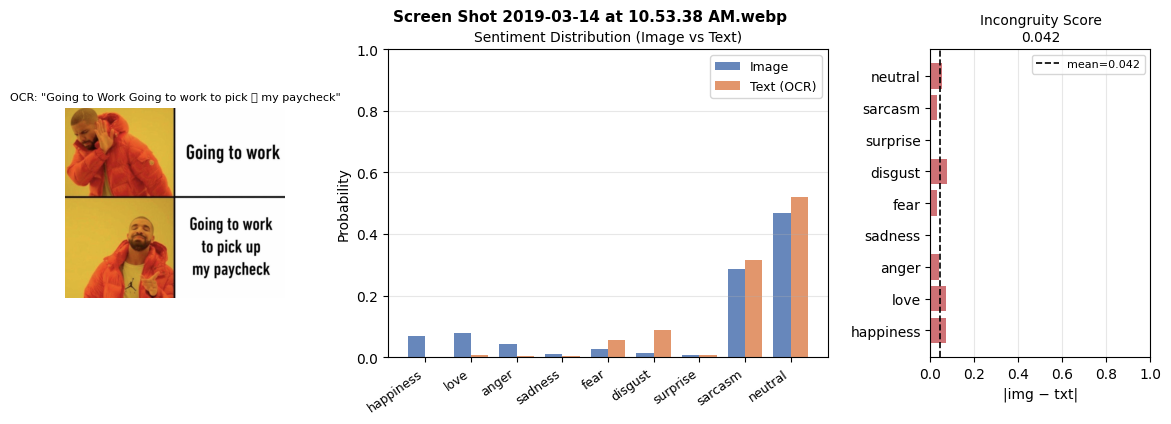

/var/folders/dl/qk95d0zj23j9sjmtb6_4gh_w0000gn/T/ipykernel_20484/62588440.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


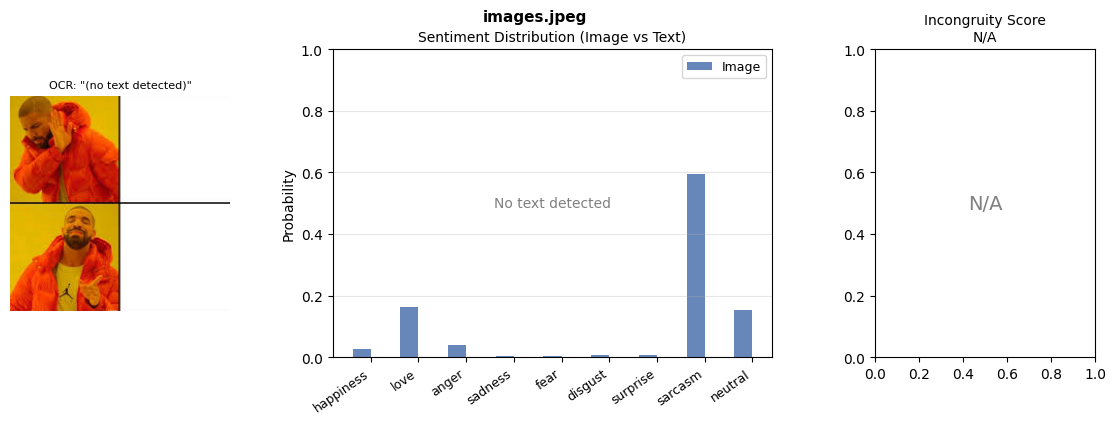

/var/folders/dl/qk95d0zj23j9sjmtb6_4gh_w0000gn/T/ipykernel_20484/62588440.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


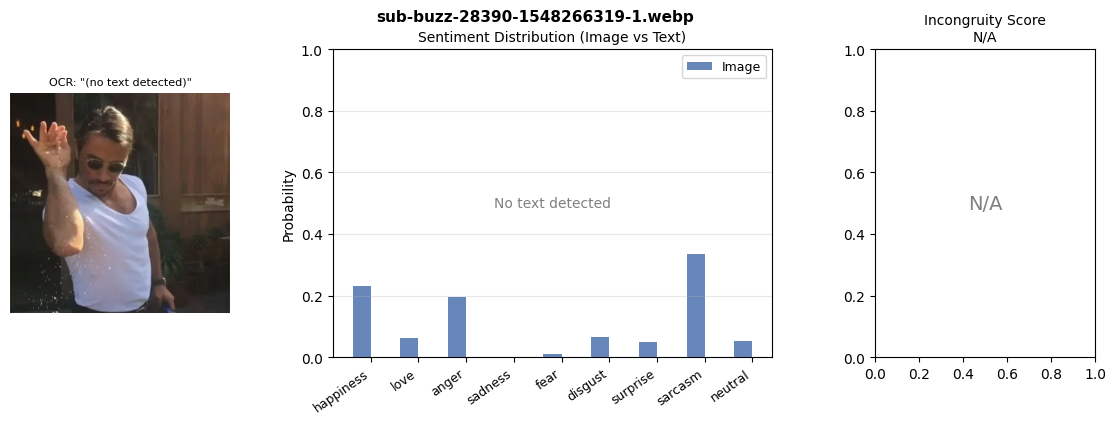

/var/folders/dl/qk95d0zj23j9sjmtb6_4gh_w0000gn/T/ipykernel_20484/62588440.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


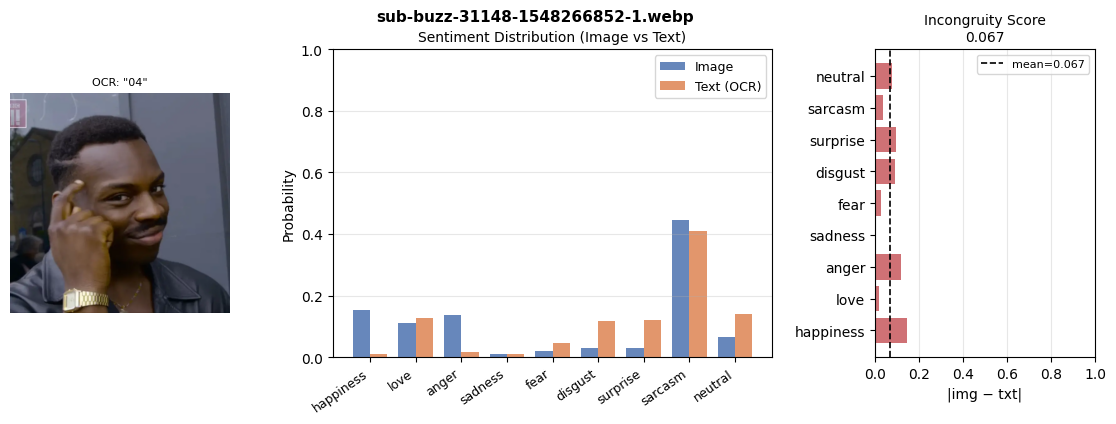

/var/folders/dl/qk95d0zj23j9sjmtb6_4gh_w0000gn/T/ipykernel_20484/62588440.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/opt/miniconda3/envs/mmai/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20844 (\N{CJK UNIFIED IDEOGRAPH-516C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/mmai/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20027 (\N{CJK UNIFIED IDEOGRAPH-4E3B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/mmai/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 19987 (\N{CJK UNIFIED IDEOGRAPH-4E13}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/mmai/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29992 (\N{CJK UN

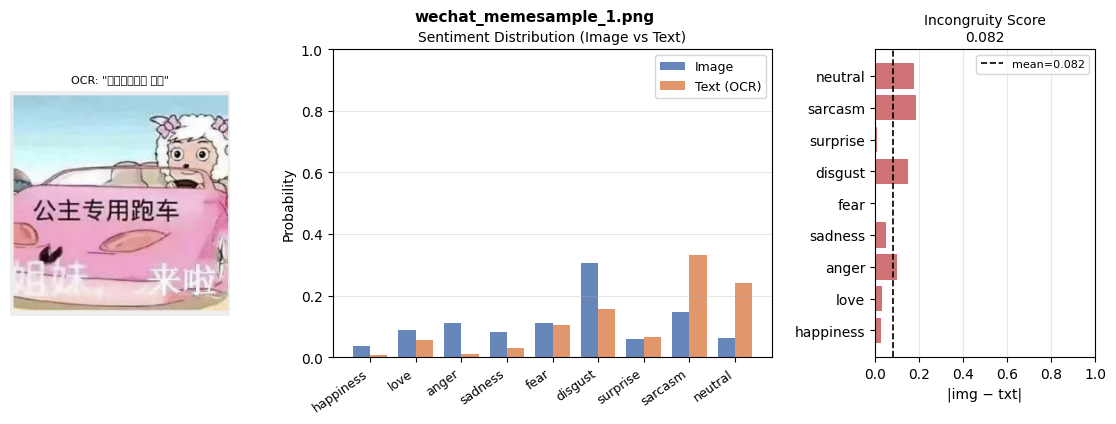

/var/folders/dl/qk95d0zj23j9sjmtb6_4gh_w0000gn/T/ipykernel_20484/62588440.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


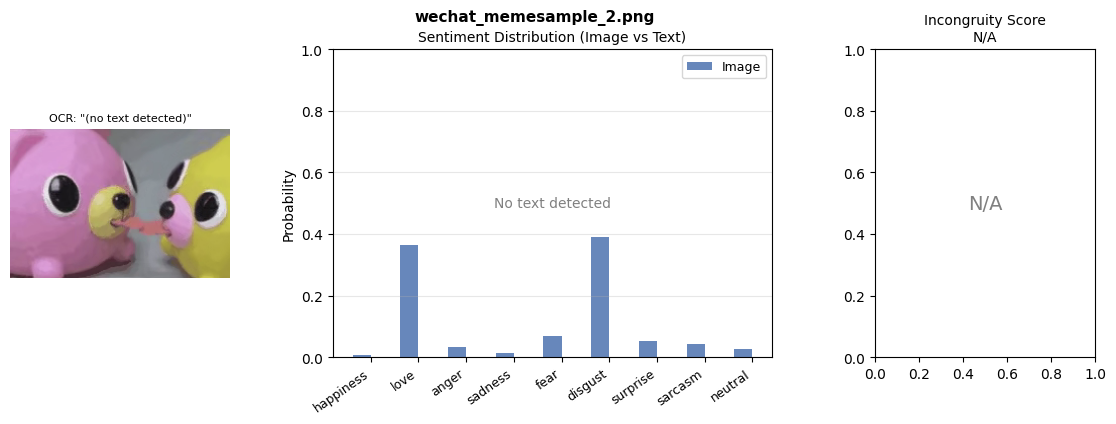

/var/folders/dl/qk95d0zj23j9sjmtb6_4gh_w0000gn/T/ipykernel_20484/62588440.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/opt/miniconda3/envs/mmai/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29240 (\N{CJK UNIFIED IDEOGRAPH-7238}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/mmai/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21568 (\N{CJK UNIFIED IDEOGRAPH-5440}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/mmai/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/mmai/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21733 (\N{CJK UN

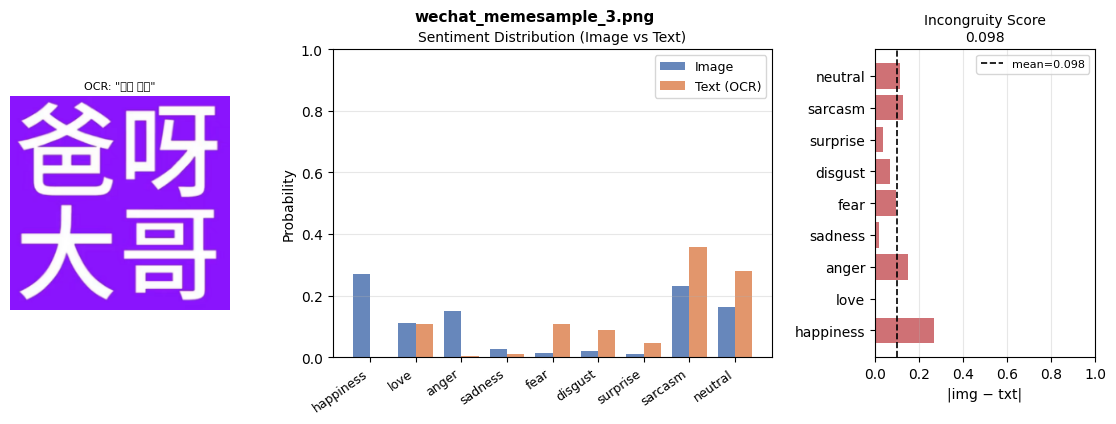

/var/folders/dl/qk95d0zj23j9sjmtb6_4gh_w0000gn/T/ipykernel_20484/62588440.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


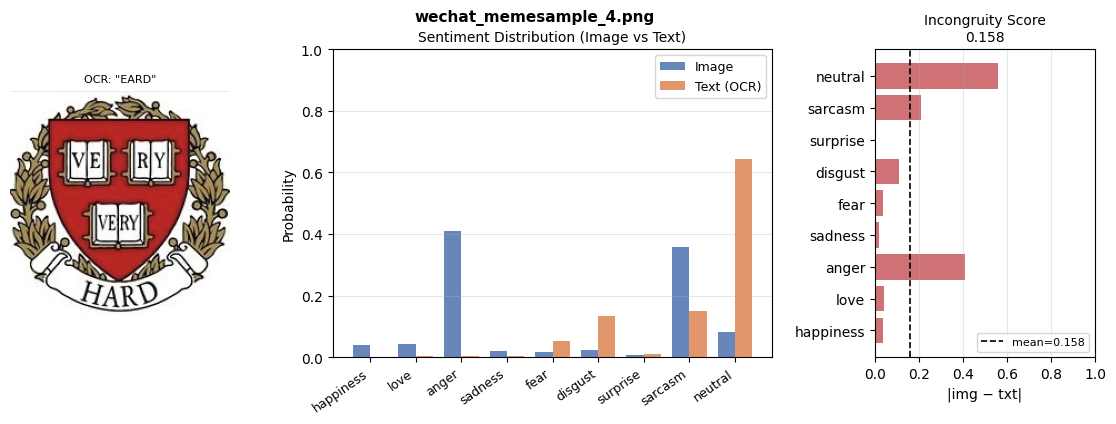

In [24]:
# ── Visualize sentiment distributions for each meme ──────────────────────────
colors_img = '#4C72B0'
colors_txt = '#DD8452'
x = np.arange(len(SENTIMENTS))
width = 0.38

for rec in records:
    fig = plt.figure(figsize=(14, 4))
    gs  = gridspec.GridSpec(1, 3, width_ratios=[1, 2, 1], wspace=0.35)

    # Left: meme image
    ax_img = fig.add_subplot(gs[0])
    ax_img.imshow(rec['img'])
    ax_img.axis('off')
    title_text = rec['ocr_text'][:60] + ('…' if len(rec['ocr_text']) > 60 else '') if rec['ocr_text'] else '(no text detected)'
    # ax_img.set_title(f'OCR: "{title_text}"', fontsize=8, wrap=True)

    # Centre: sentiment distribution bars
    ax_bar = fig.add_subplot(gs[1])
    ax_bar.bar(x - width/2, rec['img_sent'], width, label='Image', color=colors_img, alpha=0.85)
    if rec['txt_sent'] is not None:
        ax_bar.bar(x + width/2, rec['txt_sent'], width, label='Text (OCR)', color=colors_txt, alpha=0.85)
    else:
        ax_bar.text(0.5, 0.5, 'No text detected', ha='center', va='center',
                    transform=ax_bar.transAxes, fontsize=10, color='gray')
    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(SENTIMENTS, rotation=35, ha='right', fontsize=9)
    ax_bar.set_ylabel('Probability')
    ax_bar.set_ylim(0, 1)
    ax_bar.legend(fontsize=9)
    ax_bar.set_title('Sentiment Distribution (Image vs Text)', fontsize=10)
    ax_bar.grid(axis='y', alpha=0.3)

    # Right: incongruity per-dimension
    ax_inc = fig.add_subplot(gs[2])
    if rec['txt_sent'] is not None:
        dim_incong = np.abs(rec['img_sent'] - rec['txt_sent'])
        bars = ax_inc.barh(SENTIMENTS, dim_incong, color='#c44e52', alpha=0.8)
        ax_inc.set_xlim(0, 1)
        ax_inc.set_xlabel('|img − txt|')
        ax_inc.set_title(f'Incongruity Score\n{rec["incong_score"]:.3f}', fontsize=10)
        ax_inc.axvline(rec['incong_score'], color='black', linewidth=1.2,
                       linestyle='--', label=f'mean={rec["incong_score"]:.3f}')
        ax_inc.legend(fontsize=8)
        ax_inc.grid(axis='x', alpha=0.3)
    else:
        ax_inc.text(0.5, 0.5, 'N/A', ha='center', va='center',
                    transform=ax_inc.transAxes, fontsize=14, color='gray')
        ax_inc.set_title('Incongruity Score\nN/A', fontsize=10)

    # fig.suptitle(rec['name'], fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

INCONGRUITY SCORE SUMMARY  (mean |img_sentiment − txt_sentiment|)
Rank   Image                                            OCR text (trunc)                 Score
---------------------------------------------------------------------------
1      wechat_memesample_4.png                          EARD                            0.1578
2      wechat_memesample_3.png                          爸呀 大哥                           0.0976
3      wechat_memesample_1.png                          公主专用跑车 来啦                       0.0821
4      sub-buzz-31148-1548266852-1.webp                 04                              0.0667
5      Screen Shot 2019-03-14 at 10.53.38 AM.webp       Going to Work Going to work …   0.0415
6      1268.webp                                        (none)                          0.0000
7      Meme-Famous_Man_Uses_Notoriety_To_Raise_Funds_for_Multiple_Sclerosis-532aa03e3c46107a9342c7f1aad2a4a0.webp (none)                          0.0000
8      images.jpeg                      

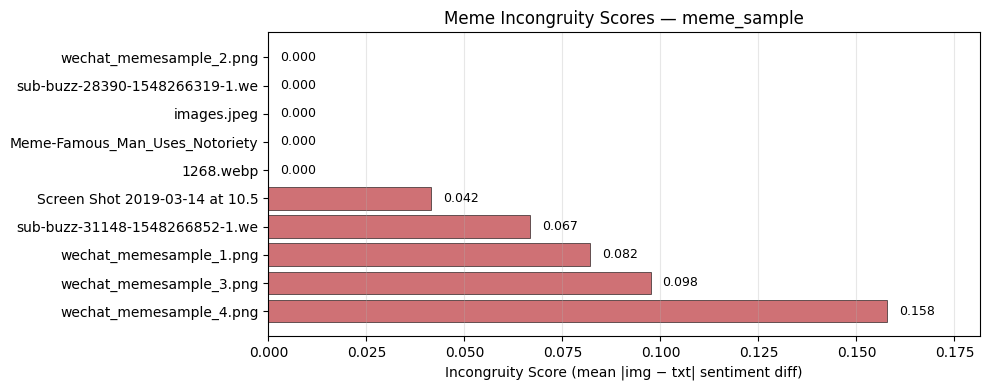

In [27]:
# ── Incongruity Score Summary ─────────────────────────────────────────────────
records_sorted = sorted(records, key=lambda r: r['incong_score'], reverse=True)

print('=' * 75)
print('INCONGRUITY SCORE SUMMARY  (mean |img_sentiment − txt_sentiment|)')
print('=' * 75)
print(f'{"Rank":<6} {"Image":<48} {"OCR text (trunc)":<30} {"Score":>7}')
print('-' * 75)
for rank, rec in enumerate(records_sorted, 1):
    ocr_short = rec['ocr_text'][:28] + '…' if len(rec['ocr_text']) > 28 else rec['ocr_text']
    ocr_short = ocr_short if ocr_short else '(none)'
    print(f'{rank:<6} {rec["name"]:<48} {ocr_short:<30} {rec["incong_score"]:>7.4f}')
print('=' * 75)
print(f'\nHighest incongruity : {records_sorted[0]["name"]} ({records_sorted[0]["incong_score"]:.4f})')
print(f'Lowest  incongruity : {records_sorted[-1]["name"]} ({records_sorted[-1]["incong_score"]:.4f})')
print(f'Mean across all     : {np.mean([r["incong_score"] for r in records]):.4f}')

# Bar chart summary
fig, ax = plt.subplots(figsize=(10, 4))
names  = [r['name'][:30] for r in records_sorted]
scores = [r['incong_score'] for r in records_sorted]
bars   = ax.barh(names, scores, color='#c44e52', alpha=0.8, edgecolor='black', linewidth=0.5)
for bar, score in zip(bars, scores):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'{score:.3f}', va='center', fontsize=9)
ax.set_xlabel('Incongruity Score (mean |img − txt| sentiment diff)')
ax.set_title('Meme Incongruity Scores — meme_sample', fontsize=12)
ax.set_xlim(0, max(scores) * 1.15)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 8b. Humor Modality Attribution — Attention Heatmap

For each meme we answer: **is it the image, the text, or the interaction that makes it funny?**

Three signals, all zero-shot (no training required):

| Signal | How | What it measures |
|--------|-----|------------------|
| **Image humor score** | CLIP image emb vs humor prompts | How funny the visual alone is |
| **Text humor score** | CLIP text emb (OCR) vs humor prompts | How funny the caption alone is |
| **Attention heatmap** | ViT last-layer attention (CLS→patches) | Which image regions CLIP focuses on |

The **interaction** (incongruity) score from Section 8 completes the picture:
high incongruity + both scores individually low → humor comes from the **gap between image and text**.


In [28]:
# ── Humor prompt space ───────────────────────────────────────────────────────
# clip_model, clip_preprocess, sent_matrix, records are all available from Section 8

HUMOR_PROMPTS = [
    'a hilarious and funny meme that makes people laugh out loud',
    'a clever and witty joke with an unexpected punchline',
    'an absurd and ridiculous scene that is comically exaggerated',
    'a relatable funny situation that people find amusing',
]
NOT_HUMOR_PROMPTS = [
    'a serious and informative image with no humor',
    'a plain ordinary scene with nothing funny about it',
]

with torch.no_grad():
    humor_tokens    = clip.tokenize(HUMOR_PROMPTS,     truncate=True).to(device)
    nothum_tokens   = clip.tokenize(NOT_HUMOR_PROMPTS, truncate=True).to(device)
    humor_vec   = F.normalize(clip_model.encode_text(humor_tokens).float(),   dim=-1).mean(0)
    nothum_vec  = F.normalize(clip_model.encode_text(nothum_tokens).float(),  dim=-1).mean(0)
    humor_vec   = F.normalize(humor_vec.unsqueeze(0),  dim=-1).squeeze(0)   # (512,)
    nothum_vec  = F.normalize(nothum_vec.unsqueeze(0), dim=-1).squeeze(0)


def humor_score(emb: torch.Tensor) -> float:
    """Relative humor score: sim(emb, funny) - sim(emb, not_funny), mapped to [0,1]."""
    emb = F.normalize(emb.float(), dim=-1)
    s_funny    = (emb @ humor_vec).item()
    s_notfunny = (emb @ nothum_vec).item()
    # map difference to 0-1 range
    raw = s_funny - s_notfunny
    return float(torch.sigmoid(torch.tensor(raw * 10)).item())


print('Humor prompts encoded.')
print(f'  humor_vec shape: {humor_vec.shape}')


Humor prompts encoded.
  humor_vec shape: torch.Size([512])


In [29]:
# ── CLIP ViT attention heatmap extractor ─────────────────────────────────────
# ViT-B/32 splits 224x224 into 7x7=49 patches.
# Last transformer block: CLS token attends to all patches → attention[0, 1:] = patch importance.

import torch.nn as nn
from torchvision.transforms.functional import to_pil_image


def get_attention_heatmap(img: 'Image.Image'):
    """
    Returns:
        heatmap_np : (224, 224) numpy array, values in [0, 1]
        img_tensor : preprocessed image tensor for encoding
    """
    x = clip_preprocess(img).unsqueeze(0).to(device)  # (1, 3, 224, 224)

    attn_weights_store = []

    last_block = clip_model.visual.transformer.resblocks[-1]
    original_forward = last_block.attn.forward

    def patched_forward(query, key, value, **kwargs):
        kwargs['need_weights'] = True
        kwargs['average_attn_weights'] = False  # keep per-head weights
        out, weights = original_forward(query, key, value, **kwargs)
        attn_weights_store.append(weights.detach().cpu())  # (1, num_heads, seq, seq)
        return out, weights

    last_block.attn.forward = patched_forward

    with torch.no_grad():
        clip_model.encode_image(x)

    last_block.attn.forward = original_forward  # restore

    if not attn_weights_store:
        return None, x

    # attn_weights: (1, num_heads, seq_len, seq_len)  seq_len = 50 (1 CLS + 49 patches)
    attn = attn_weights_store[0][0]          # (num_heads, 50, 50)
    cls_attn = attn[:, 0, 1:]               # (num_heads, 49) — CLS attending to patches
    cls_attn = cls_attn.mean(0)             # (49,) — average over heads
    cls_attn = cls_attn - cls_attn.min()
    cls_attn = cls_attn / (cls_attn.max() + 1e-8)  # normalize to [0, 1]

    # Reshape to 7x7 and upsample to 224x224
    heatmap = cls_attn.reshape(7, 7).numpy()
    from PIL import Image as _PIL
    heatmap_img = _PIL.fromarray((heatmap * 255).astype('uint8')).resize(
        (224, 224), resample=_PIL.BILINEAR
    )
    return np.array(heatmap_img) / 255.0, x


print('Attention heatmap extractor defined.')
print('Architecture: CLIP ViT-B/32, last block, CLS→patch attention, averaged over heads.')


Attention heatmap extractor defined.
Architecture: CLIP ViT-B/32, last block, CLS→patch attention, averaged over heads.


In [30]:
# ── Run humor attribution inference on all meme_sample images ────────────────
import matplotlib.cm as cm

humor_records = []

for rec in records:
    img  = rec['img'].resize((224, 224))
    name = rec['name']

    # ── Image humor score ─────────────────────────────────────────────────────
    x = clip_preprocess(rec['img']).unsqueeze(0).to(device)
    with torch.no_grad():
        img_emb = clip_model.encode_image(x).float()   # (1, 512)
    img_humor = humor_score(img_emb.squeeze(0))

    # ── Text humor score ──────────────────────────────────────────────────────
    txt_humor = None  # no text detected
    _ocr_raw = rec['ocr_text'].strip() if rec['ocr_text'] else ''
    _ocr = rec['ocr_en'].strip() if rec['ocr_en'] else ''
    _has_text = (len(_ocr_raw) >= 3 and any(c.isalpha() for c in _ocr_raw)) \
                and len(_ocr) >= 3
    if _has_text:
        tokens = clip.tokenize([_ocr], truncate=True).to(device)
        with torch.no_grad():
            txt_emb = clip_model.encode_text(tokens).float()
        txt_humor = humor_score(txt_emb.squeeze(0))

    # ── Attention heatmap ─────────────────────────────────────────────────────
    heatmap, _ = get_attention_heatmap(rec['img'])

    # ── Modality attribution label ────────────────────────────────────────────
    incong = rec['incong_score']
    if txt_humor is None:
        attribution = 'Image-only'
        attr_color  = '#4C72B0'
    else:
        gap = abs(img_humor - txt_humor)
        if incong > 0.06 and gap < 0.15:
            attribution = 'Interaction'
            attr_color  = '#9467bd'
        elif img_humor > txt_humor + 0.1:
            attribution = 'Image-driven'
            attr_color  = '#4C72B0'
        elif txt_humor > img_humor + 0.1:
            attribution = 'Text-driven'
            attr_color  = '#DD8452'
        else:
            attribution = 'Balanced'
            attr_color  = '#2ca02c'

    humor_records.append({
        **rec,
        'img_humor':   img_humor,
        'txt_humor':   txt_humor,
        'heatmap':     heatmap,
        'attribution': attribution,
        'attr_color':  attr_color,
    })

print(f'Processed {len(humor_records)} memes.')
print()
print(f'{"Meme":<50} {"Img-Humor":>10} {"Txt-Humor":>10} {"Incongruity":>12} {"Attribution":<14}')
print('-' * 100)
for hr in humor_records:
    _th = f'{hr["txt_humor"]:>10.3f}' if hr['txt_humor'] is not None else '       N/A'
    print(f'{hr["name"]:<50} {hr["img_humor"]:>10.3f} {_th} {hr["incong_score"]:>12.4f} {hr["attribution"]:<14}')


Processed 10 memes.

Meme                                                Img-Humor  Txt-Humor  Incongruity Attribution   
----------------------------------------------------------------------------------------------------
1268.webp                                               0.495      0.500       0.0000 Balanced      
Meme-Famous_Man_Uses_Notoriety_To_Raise_Funds_for_Multiple_Sclerosis-532aa03e3c46107a9342c7f1aad2a4a0.webp      0.510      0.500       0.0000 Balanced      
Screen Shot 2019-03-14 at 10.53.38 AM.webp              0.532      0.475       0.0415 Balanced      
images.jpeg                                             0.502      0.500       0.0000 Balanced      
sub-buzz-28390-1548266319-1.webp                        0.510      0.500       0.0000 Balanced      
sub-buzz-31148-1548266852-1.webp                        0.513      0.453       0.0667 Interaction   
wechat_memesample_1.png                                 0.465      0.489       0.0821 Interaction   
wechat_memesam

/var/folders/dl/qk95d0zj23j9sjmtb6_4gh_w0000gn/T/ipykernel_20484/2520398329.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


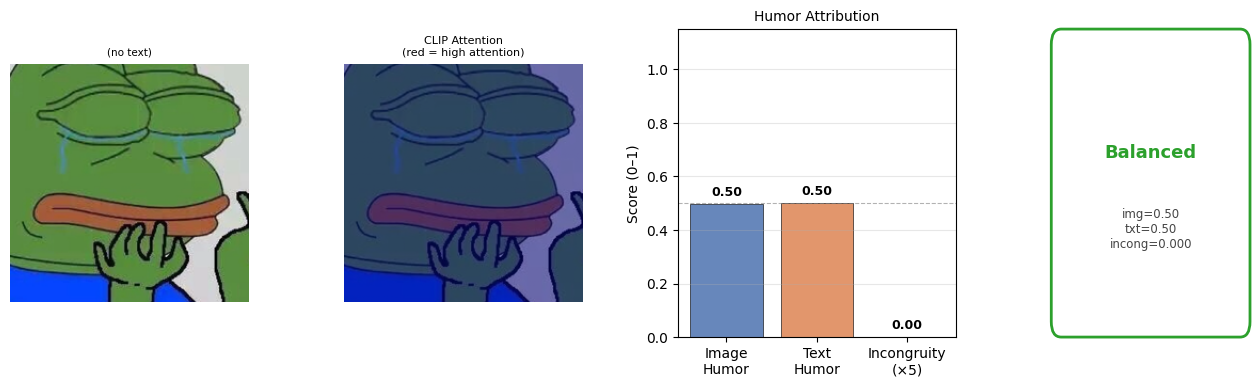

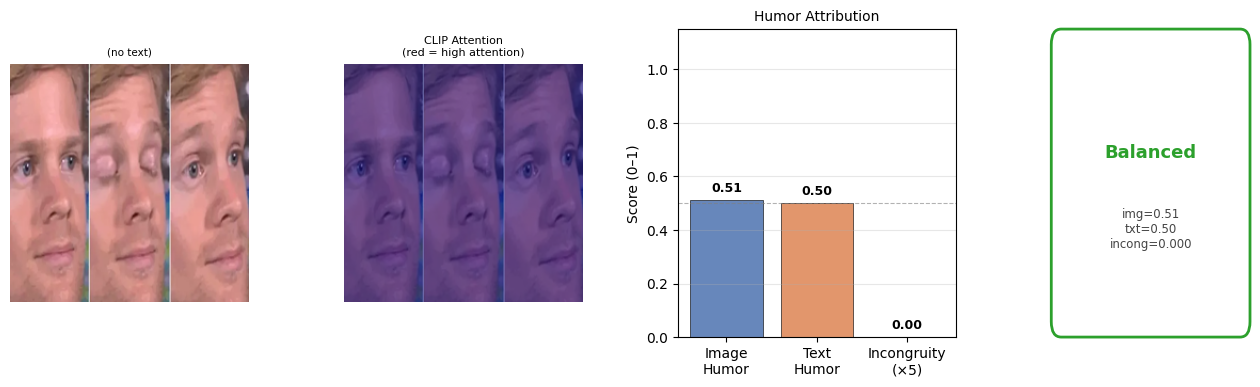

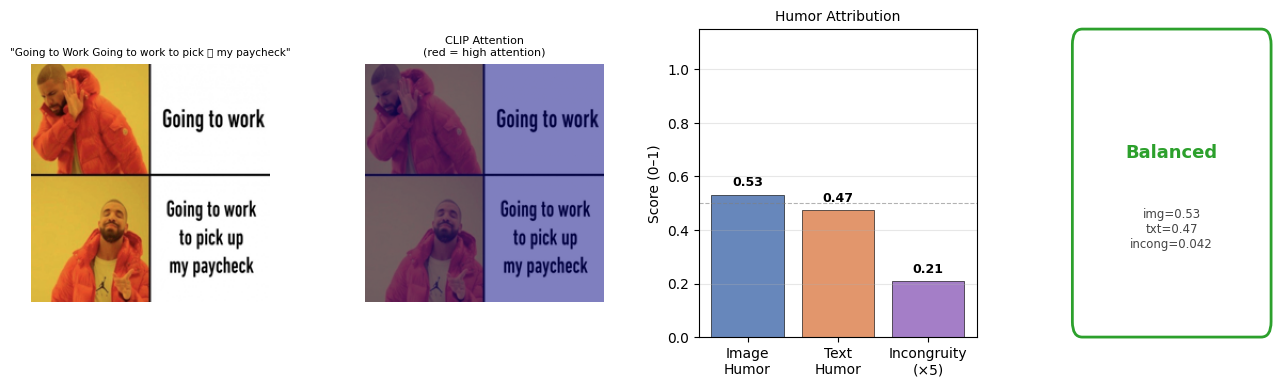

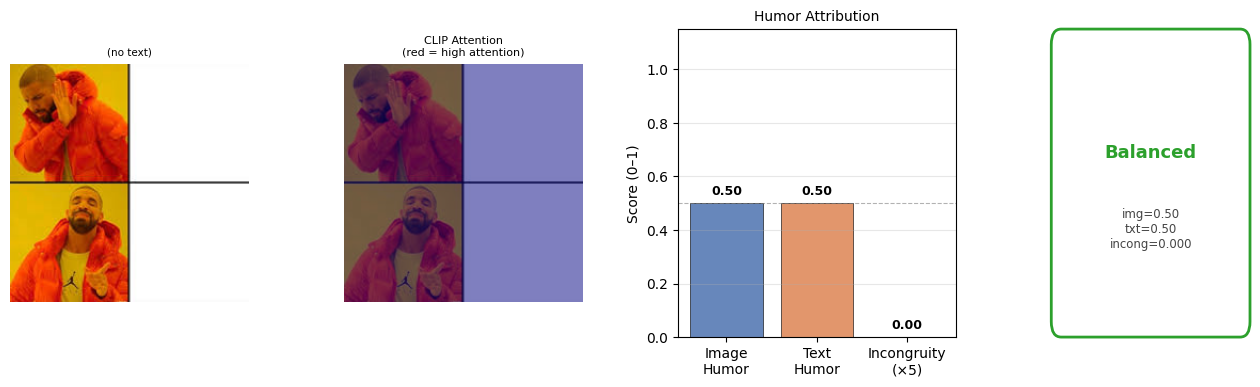

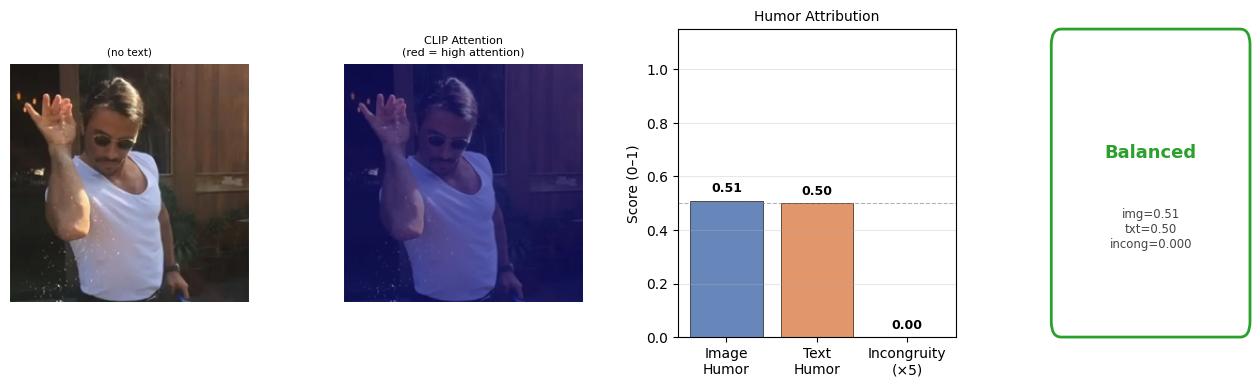

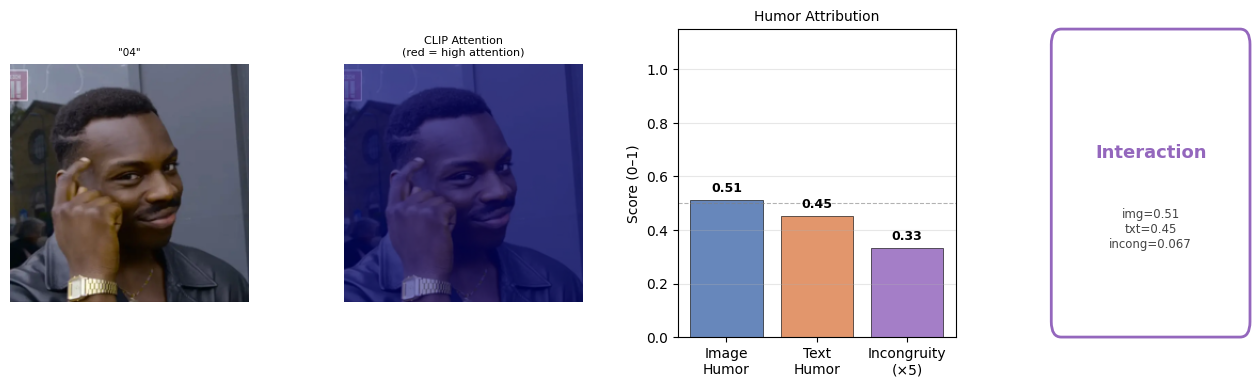

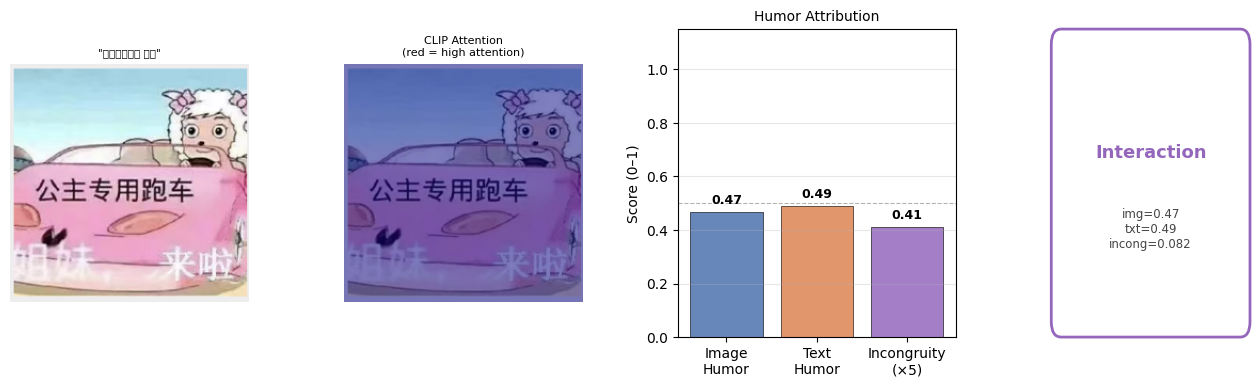

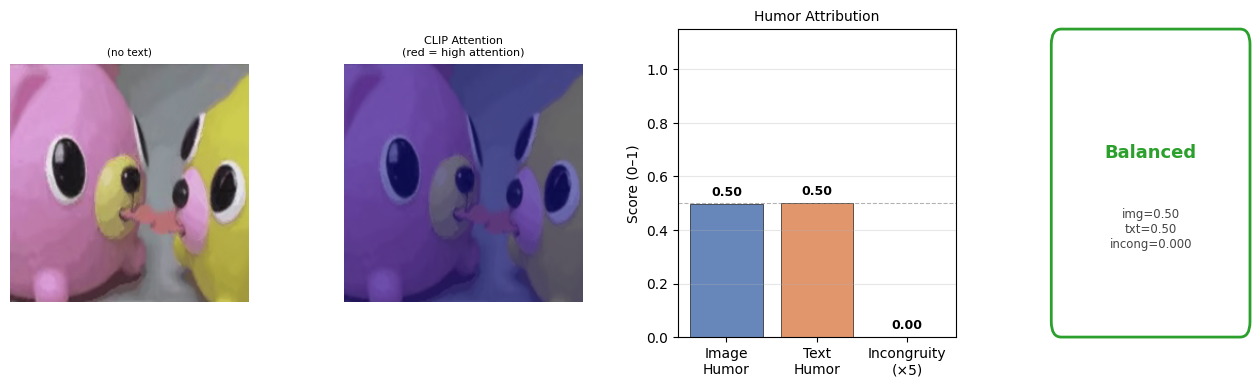

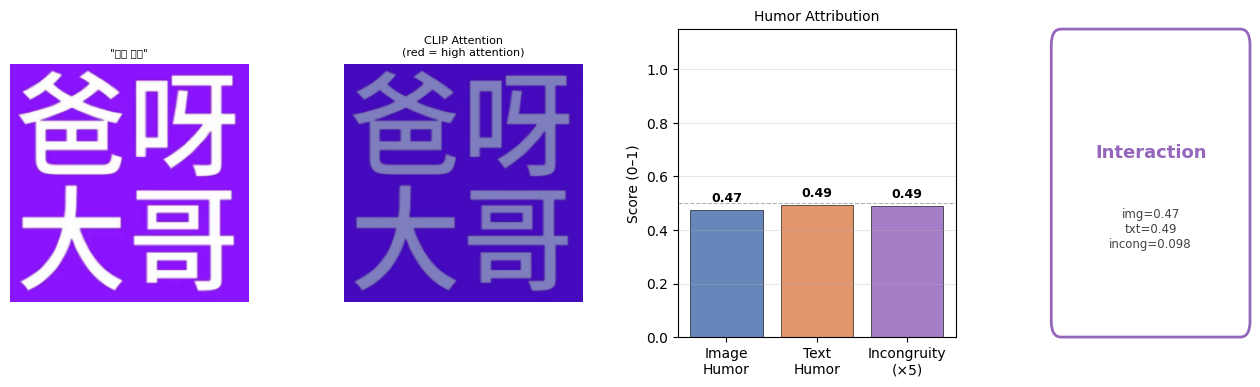

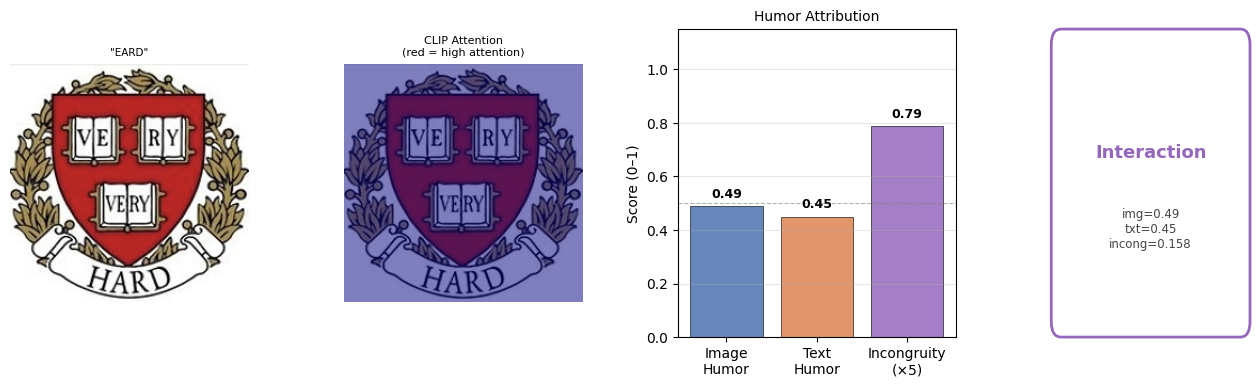

In [46]:
# ── Per-meme visualization: image + heatmap + humor attribution bars ─────────
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import matplotlib.patches as mpatches

for hr in humor_records:
    fig = plt.figure(figsize=(16, 4))
    gs  = gridspec.GridSpec(1, 4, width_ratios=[1.2, 1.2, 1.4, 1], wspace=0.4)

    img_224 = hr['img'].resize((224, 224))

    # ── Panel 1: original meme ────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0])
    ax1.imshow(img_224)
    ax1.axis('off')
    ocr_short = hr['ocr_text'][:50] + '…' if len(hr['ocr_text']) > 50 else hr['ocr_text']
    ax1.set_title(f'"{ocr_short}"' if ocr_short else '(no text)', fontsize=7.5)

    # ── Panel 2: attention heatmap overlay ───────────────────────────────────
    ax2 = fig.add_subplot(gs[1])
    img_arr = np.array(img_224)
    if hr['heatmap'] is not None:
        hm_colored = cm.jet(hr['heatmap'])[:, :, :3]          # (224,224,3)
        overlay    = 0.5 * img_arr / 255.0 + 0.5 * hm_colored
        overlay    = np.clip(overlay, 0, 1)
        ax2.imshow(overlay)
    else:
        ax2.imshow(img_arr)
        ax2.text(0.5, 0.5, 'N/A', ha='center', va='center',
                 transform=ax2.transAxes, color='white', fontsize=14)
    ax2.axis('off')
    ax2.set_title('CLIP Attention\n(red = high attention)', fontsize=8)

    # ── Panel 3: humor attribution bars ──────────────────────────────────────
    ax3 = fig.add_subplot(gs[2])
    categories = ['Image\nHumor', 'Text\nHumor', 'Incongruity\n(×5)']
    _txt_val   = hr['txt_humor']
    values     = [hr['img_humor'], _txt_val if _txt_val is not None else 0.0, min(hr['incong_score'] * 5, 1.0)]
    _raw_vals  = [hr['img_humor'], _txt_val, min(hr['incong_score'] * 5, 1.0)]
    bar_colors = ['#4C72B0', '#DD8452', '#9467bd']
    bars = ax3.bar(categories, values, color=bar_colors, alpha=0.85,
                   edgecolor='black', linewidth=0.5)
    for bar, val, raw in zip(bars, values, _raw_vals):
        label = 'N/A' if raw is None else f'{val:.2f}'
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 label, ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax3.set_ylim(0, 1.15)
    ax3.set_ylabel('Score (0–1)')
    ax3.set_title('Humor Attribution', fontsize=10)
    ax3.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax3.grid(axis='y', alpha=0.3)

    # ── Panel 4: attribution label ────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[3])
    ax4.axis('off')
    ax4.set_facecolor(hr['attr_color'] + '22')  # light tint
    ax4.text(0.5, 0.6, hr['attribution'], ha='center', va='center',
             fontsize=13, fontweight='bold', color=hr['attr_color'],
             transform=ax4.transAxes)
    _txt_label = 'N/A' if hr['txt_humor'] is None else f'{hr["txt_humor"]:.2f}'
    ax4.text(0.5, 0.35,
             f'img={hr["img_humor"]:.2f}\ntxt={_txt_label}\nincong={hr["incong_score"]:.3f}',
             ha='center', va='center', fontsize=8.5, color='#444',
             transform=ax4.transAxes)
    patch = mpatches.FancyBboxPatch((0.05, 0.05), 0.9, 0.9,
                                     boxstyle='round,pad=0.05',
                                     linewidth=2, edgecolor=hr['attr_color'],
                                     facecolor='none',
                                     transform=ax4.transAxes, clip_on=False)
    ax4.add_patch(patch)

    # fig.suptitle(hr['name'], fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()


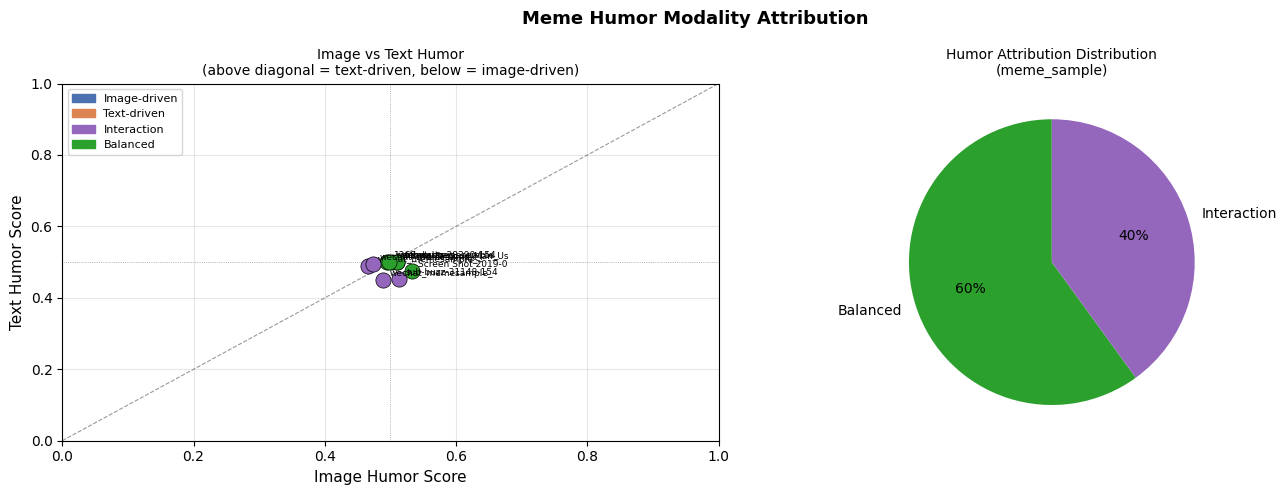

Saved: results/humor_attribution_summary.png


In [32]:
# ── Summary: humor attribution across all memes ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scatter img_humor vs txt_humor, colored by attribution
ax = axes[0]
for hr in humor_records:
    ax.scatter(hr['img_humor'], hr['txt_humor'],
               c=hr['attr_color'], s=120, zorder=3,
               edgecolors='black', linewidths=0.5)
    ax.annotate(hr['name'][:18], (hr['img_humor'], hr['txt_humor']),
                fontsize=6.5, textcoords='offset points', xytext=(5, 3))

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.4, label='img = txt')
ax.axhline(0.5, color='gray', linewidth=0.5, linestyle=':')
ax.axvline(0.5, color='gray', linewidth=0.5, linestyle=':')
ax.set_xlabel('Image Humor Score', fontsize=11)
ax.set_ylabel('Text Humor Score', fontsize=11)
ax.set_title('Image vs Text Humor\n(above diagonal = text-driven, below = image-driven)', fontsize=10)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
legend_patches = [
    mpatches.Patch(color='#4C72B0', label='Image-driven'),
    mpatches.Patch(color='#DD8452', label='Text-driven'),
    mpatches.Patch(color='#9467bd', label='Interaction'),
    mpatches.Patch(color='#2ca02c', label='Balanced'),
]
ax.legend(handles=legend_patches, fontsize=8)
ax.grid(alpha=0.3)

# Right: attribution distribution pie chart
ax2 = axes[1]
from collections import Counter
attr_counts = Counter(hr['attribution'] for hr in humor_records)
color_map = {'Image-driven': '#4C72B0', 'Text-driven': '#DD8452',
             'Interaction': '#9467bd', 'Balanced': '#2ca02c'}
labels = list(attr_counts.keys())
sizes  = [attr_counts[l] for l in labels]
colors = [color_map.get(l, '#aaa') for l in labels]
ax2.pie(sizes, labels=labels, colors=colors, autopct='%1.0f%%',
        startangle=90, textprops={'fontsize': 10})
ax2.set_title('Humor Attribution Distribution\n(meme_sample)', fontsize=10)

plt.suptitle('Meme Humor Modality Attribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/humor_attribution_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/humor_attribution_summary.png')


---
## 9. MMSD 2.0 — Does Incongruity-Aware Fusion Help Sarcasm Detection?

**Research question**: The incongruity module was designed around the intuition that
sarcasm/irony arises when image and text *disagree* emotionally. MMSD 2.0 is a direct
test of this hypothesis — does explicitly modeling sentiment incongruity improve
sarcasm classification over a plain concat baseline?

**Experiment design** (all models use frozen CLIP ViT-B/32, no fine-tuning of backbone):

| Model | Description |
|-------|-------------|
| CLIP Zero-Shot | Cosine sim against "sarcastic" / "non-sarcastic" prompts |
| CLIP Concat | concat(img_emb, txt_emb) → Linear(1024→2), trained |
| CLIP Incong Fusion | SentimentIncongruityFusion + MLP head, trained |

Same architecture as Section 7, swapped dataset only.

In [29]:
# ── MMSD 2.0 dataset for incongruity experiment ───────────────────────────────
from datasets import load_dataset as _load_ds
import random as _random

MMSD_INCONG_SEED    = 42
MMSD_INCONG_TRAIN_N = 500   # subset of train split for fast training
MMSD_INCONG_VAL_N   = 200
MMSD_INCONG_TEST_N  = 200   # held-out test

_mmsd_full = _load_ds('coderchen01/MMSD2.0', 'mmsd-v2')
_rng = _random.Random(MMSD_INCONG_SEED)

def _sample(split, n):
    idx = _rng.sample(range(len(_mmsd_full[split])), min(n, len(_mmsd_full[split])))
    return [_mmsd_full[split][i] for i in idx]

mmsd_train_rows = _sample('train',      MMSD_INCONG_TRAIN_N)
mmsd_val_rows   = _sample('validation', MMSD_INCONG_VAL_N)
mmsd_test_rows  = _sample('test',       MMSD_INCONG_TEST_N)

from collections import Counter
print(f'MMSD 2.0 splits for incongruity experiment:')
print(f'  train : {len(mmsd_train_rows)}  labels={dict(Counter(r["label"] for r in mmsd_train_rows))}')
print(f'  val   : {len(mmsd_val_rows)}    labels={dict(Counter(r["label"] for r in mmsd_val_rows))}')
print(f'  test  : {len(mmsd_test_rows)}   labels={dict(Counter(r["label"] for r in mmsd_test_rows))}')

MMSD 2.0 splits for incongruity experiment:
  train : 500  labels={0: 261, 1: 239}
  val   : 200    labels={0: 114, 1: 86}
  test  : 200   labels={0: 113, 1: 87}


In [33]:
# ── MMSD 2.0 Dataset class (reuses clip_preprocess & clip.tokenize) ───────────
class MMSDDataset(Dataset):
    def __init__(self, rows):
        self.rows = rows

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row   = self.rows[idx]
        image = clip_preprocess(row['image'].convert('RGB'))   # (3, 224, 224)
        text  = clip.tokenize([row['text']], truncate=True).squeeze(0)  # (77,)
        label = int(row['label'])                               # 0 or 1
        return image, text, label

mmsd_trainset = MMSDDataset(mmsd_train_rows)
mmsd_valset   = MMSDDataset(mmsd_val_rows)
mmsd_testset  = MMSDDataset(mmsd_test_rows)

MMSD_BATCH = 32
mmsd_traind = DataLoader(mmsd_trainset, batch_size=MMSD_BATCH, shuffle=True)
mmsd_vald   = DataLoader(mmsd_valset,   batch_size=MMSD_BATCH)
mmsd_testd  = DataLoader(mmsd_testset,  batch_size=MMSD_BATCH)
print('DataLoaders ready.')

DataLoaders ready.


In [34]:
# ── Baseline 1: CLIP Zero-Shot sarcasm detection ─────────────────────────────
# Compare image+text embedding against "sarcastic" vs "non-sarcastic" prompts

_sarc_prompts     = ['a sarcastic meme with ironic meaning',
                     'an image where the caption contradicts the visual']
_nonsarc_prompts  = ['a sincere and straightforward meme',
                     'an image where the caption matches the visual meaning']

with torch.no_grad():
    _sarc_emb    = clip_model.encode_text(
        clip.tokenize(_sarc_prompts, truncate=True).to(device)).float().mean(0)
    _nonsarc_emb = clip_model.encode_text(
        clip.tokenize(_nonsarc_prompts, truncate=True).to(device)).float().mean(0)
    _sarc_emb    = F.normalize(_sarc_emb.unsqueeze(0), dim=-1)
    _nonsarc_emb = F.normalize(_nonsarc_emb.unsqueeze(0), dim=-1)

zs_preds, zs_gts = [], []
for imgs, texts, labels in mmsd_testd:
    imgs  = imgs.to(device)
    texts = texts.to(device)
    with torch.no_grad():
        img_emb = F.normalize(clip_model.encode_image(imgs).float(), dim=-1)
        txt_emb = F.normalize(clip_model.encode_text(texts).float(), dim=-1)
        fused   = F.normalize((img_emb + txt_emb) / 2, dim=-1)   # avg pooling
        sim_sarc    = (fused @ _sarc_emb.T).squeeze(-1)
        sim_nonsarc = (fused @ _nonsarc_emb.T).squeeze(-1)
        pred = (sim_sarc > sim_nonsarc).long()
    zs_preds.extend(pred.cpu().tolist())
    zs_gts.extend(labels.tolist())

from sklearn.metrics import accuracy_score, f1_score, classification_report
zs_acc = accuracy_score(zs_gts, zs_preds)
zs_f1  = f1_score(zs_gts, zs_preds, average='macro')
print(f'CLIP Zero-Shot  →  Acc: {zs_acc:.3f}  Macro-F1: {zs_f1:.3f}')
print(classification_report(zs_gts, zs_preds, target_names=['Non-sarcastic','Sarcastic']))

CLIP Zero-Shot  →  Acc: 0.620  Macro-F1: 0.582
               precision    recall  f1-score   support

Non-sarcastic       0.63      0.81      0.71       113
    Sarcastic       0.60      0.37      0.46        87

     accuracy                           0.62       200
    macro avg       0.61      0.59      0.58       200
 weighted avg       0.62      0.62      0.60       200



In [35]:
# ── Baseline 2: CLIP Concat → Linear (no incongruity module) ─────────────────
import os as _os

MMSD_CONCAT_CKPT = 'artifacts/mmsd_concat.pt'
_os.makedirs('artifacts', exist_ok=True)

class MMSDConcat(nn.Module):
    def __init__(self):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(1024, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 2)
        )
    def forward(self, imgs, texts):
        with torch.no_grad():
            img_emb = F.normalize(clip_model.encode_image(imgs).float(), dim=-1)
            txt_emb = F.normalize(clip_model.encode_text(texts).float(), dim=-1)
        return self.head(torch.cat([img_emb, txt_emb], dim=-1))

def train_mmsd(model, name, ckpt, epochs=15, lr=5e-4):
    if _os.path.exists(ckpt):
        print(f'[{name}] loading from {ckpt}')
        model.load_state_dict(torch.load(ckpt, map_location=device))
        model.to(device)
        return model
    model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    crit = nn.CrossEntropyLoss()
    best_val, best_sd = 0, None
    for ep in range(epochs):
        model.train()
        for imgs, texts, labels in mmsd_traind:
            imgs, texts, labels = imgs.to(device), texts.to(device), labels.to(device)
            loss = crit(model(imgs, texts), labels)
            opt.zero_grad(); loss.backward(); opt.step()
        model.eval()
        correct = total = 0
        with torch.no_grad():
            for imgs, texts, labels in mmsd_vald:
                imgs, texts, labels = imgs.to(device), texts.to(device), labels.to(device)
                pred = model(imgs, texts).argmax(1)
                correct += (pred == labels).sum().item()
                total   += labels.size(0)
        val_acc = correct / total
        if val_acc > best_val:
            best_val = val_acc
            best_sd  = {k: v.clone() for k, v in model.state_dict().items()}
        print(f'  ep {ep+1:02d}  val_acc={val_acc:.3f}')
    model.load_state_dict(best_sd)
    torch.save(best_sd, ckpt)
    print(f'[{name}] best val_acc={best_val:.3f}  saved to {ckpt}')
    return model

mmsd_concat_model = train_mmsd(MMSDConcat(), 'Concat', MMSD_CONCAT_CKPT)

  ep 01  val_acc=0.725
  ep 02  val_acc=0.760
  ep 03  val_acc=0.785
  ep 04  val_acc=0.785
  ep 05  val_acc=0.805
  ep 06  val_acc=0.795
  ep 07  val_acc=0.810
  ep 08  val_acc=0.810
  ep 09  val_acc=0.815
  ep 10  val_acc=0.820
  ep 11  val_acc=0.825
  ep 12  val_acc=0.830
  ep 13  val_acc=0.835
  ep 14  val_acc=0.840
  ep 15  val_acc=0.840
[Concat] best val_acc=0.840  saved to artifacts/mmsd_concat.pt


In [41]:
# ── Model 3: CLIP Sentiment-Incongruity-Aware Fusion ─────────────────────────
# Reuses CLIPImageEncoder, CLIPTextEncoder, SentimentIncongruityFusion, MLP
# from Section 7 — only the dataset changes.

MMSD_INCONG_CKPT = 'artifacts/mmsd_incong_fusion.pt'
MMSD_NUM_CLASSES = 2

class MMSDIncongrFusion(nn.Module):
    def __init__(self, output_dim=64, num_sentiments=5):
        super().__init__()
        self.img_enc  = CLIPImageEncoder(output_dim)
        self.txt_enc  = CLIPTextEncoder(output_dim)
        self.fusion   = SentimentIncongruityFusion(output_dim, num_sentiments)
        self.head     = nn.Sequential(
            nn.Linear(output_dim + num_sentiments, 256),
            nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, MMSD_NUM_CLASSES)
        )
    def forward(self, imgs, texts):
        img_emb  = self.img_enc(imgs)
        txt_emb  = self.txt_enc(texts)
        fused    = self.fusion([img_emb, txt_emb])
        return self.head(fused)

def train_mmsd_incong(model, ckpt, epochs=15, lr=5e-4):
    if _os.path.exists(ckpt):
        print(f'[IncongrFusion] loading from {ckpt}')
        model.load_state_dict(torch.load(ckpt, map_location=device))
        model.to(device)
        return model
    model.to(device)
    opt  = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    crit = nn.CrossEntropyLoss()
    best_val, best_sd = 0, None
    for ep in range(epochs):
        model.train()
        for imgs, texts, labels in mmsd_traind:
            imgs, texts, labels = imgs.to(device), texts.to(device), labels.to(device)
            loss = crit(model(imgs, texts), labels)
            opt.zero_grad(); loss.backward(); opt.step()
        model.eval()
        correct = total = 0
        with torch.no_grad():
            for imgs, texts, labels in mmsd_vald:
                imgs, texts, labels = imgs.to(device), texts.to(device), labels.to(device)
                pred = model(imgs, texts).argmax(1)
                correct += (pred == labels).sum().item()
                total   += labels.size(0)
        val_acc = correct / total
        if val_acc > best_val:
            best_val = val_acc
            best_sd  = {k: v.clone() for k, v in model.state_dict().items()}
        print(f'  ep {ep+1:02d}  val_acc={val_acc:.3f}')
    model.load_state_dict(best_sd)
    torch.save(best_sd, ckpt)
    print(f'[IncongrFusion] best val_acc={best_val:.3f}  saved to {ckpt}')
    return model

mmsd_incong_model = train_mmsd_incong(MMSDIncongrFusion(), MMSD_INCONG_CKPT)

  ep 01  val_acc=0.715
  ep 02  val_acc=0.640
  ep 03  val_acc=0.700
  ep 04  val_acc=0.720
  ep 05  val_acc=0.780
  ep 06  val_acc=0.795
  ep 07  val_acc=0.805
  ep 08  val_acc=0.805
  ep 09  val_acc=0.820
  ep 10  val_acc=0.810
  ep 11  val_acc=0.835
  ep 12  val_acc=0.840
  ep 13  val_acc=0.845
  ep 14  val_acc=0.855
  ep 15  val_acc=0.855
[IncongrFusion] best val_acc=0.855  saved to artifacts/mmsd_incong_fusion.pt


In [42]:
# ── Evaluate all three models on MMSD 2.0 test set ───────────────────────────
from sklearn.metrics import accuracy_score, f1_score, classification_report

def eval_mmsd(model, name, forward_fn=None):
    model.eval()
    preds, gts = [], []
    with torch.no_grad():
        for imgs, texts, labels in mmsd_testd:
            imgs, texts = imgs.to(device), texts.to(device)
            if forward_fn:
                logits = forward_fn(imgs, texts)
            else:
                logits = model(imgs, texts)
            preds.extend(logits.argmax(1).cpu().tolist())
            gts.extend(labels.tolist())
    acc = accuracy_score(gts, preds)
    f1  = f1_score(gts, preds, average='macro')
    f1_sarc = f1_score(gts, preds, average=None)[1]   # F1 for Sarcastic class
    return acc, f1, f1_sarc, preds, gts

concat_acc,  concat_f1,  concat_f1s,  concat_preds,  concat_gts  = eval_mmsd(mmsd_concat_model,  'Concat')
incong_acc,  incong_f1,  incong_f1s,  incong_preds,  incong_gts  = eval_mmsd(mmsd_incong_model,  'IncongrFusion')

mmsd_results_cmp = {
    'CLIP Zero-Shot':      {'acc': zs_acc,     'macro_f1': zs_f1,     'sarc_f1': f1_score(zs_gts,     zs_preds,     average=None)[1]},
    'CLIP Concat':         {'acc': concat_acc,  'macro_f1': concat_f1,  'sarc_f1': concat_f1s},
    'CLIP Incong Fusion':  {'acc': incong_acc,  'macro_f1': incong_f1,  'sarc_f1': incong_f1s},
}

print('=' * 62)
print('MMSD 2.0 SARCASM DETECTION — MODEL COMPARISON')
print('=' * 62)
print(f'{"Model":<22} {"Acc":>8} {"Macro-F1":>10} {"Sarc-F1":>10}')
print('-' * 52)
for name, m in mmsd_results_cmp.items():
    print(f'{name:<22} {m["acc"]:>8.3f} {m["macro_f1"]:>10.3f} {m["sarc_f1"]:>10.3f}')
print('=' * 62)

delta_f1 = mmsd_results_cmp['CLIP Incong Fusion']['macro_f1'] - mmsd_results_cmp['CLIP Concat']['macro_f1']
print(f'\nIncongruity fusion vs Concat: Macro-F1 {"▲" if delta_f1>0 else "▼"} {abs(delta_f1):.3f}')
if delta_f1 > 0.01:
    print('→ Incongruity module HELPS: sentiment disagreement is a useful signal for sarcasm.')
elif delta_f1 < -0.01:
    print('→ Incongruity module HURTS: the added complexity is not beneficial here.')
else:
    print('→ No significant difference: incongruity signal is neutral for this task.')

MMSD 2.0 SARCASM DETECTION — MODEL COMPARISON
Model                       Acc   Macro-F1    Sarc-F1
----------------------------------------------------
CLIP Zero-Shot            0.620      0.582      0.457
CLIP Concat               0.810      0.809      0.793
CLIP Incong Fusion        0.805      0.804      0.791

Incongruity fusion vs Concat: Macro-F1 ▼ 0.005
→ No significant difference: incongruity signal is neutral for this task.


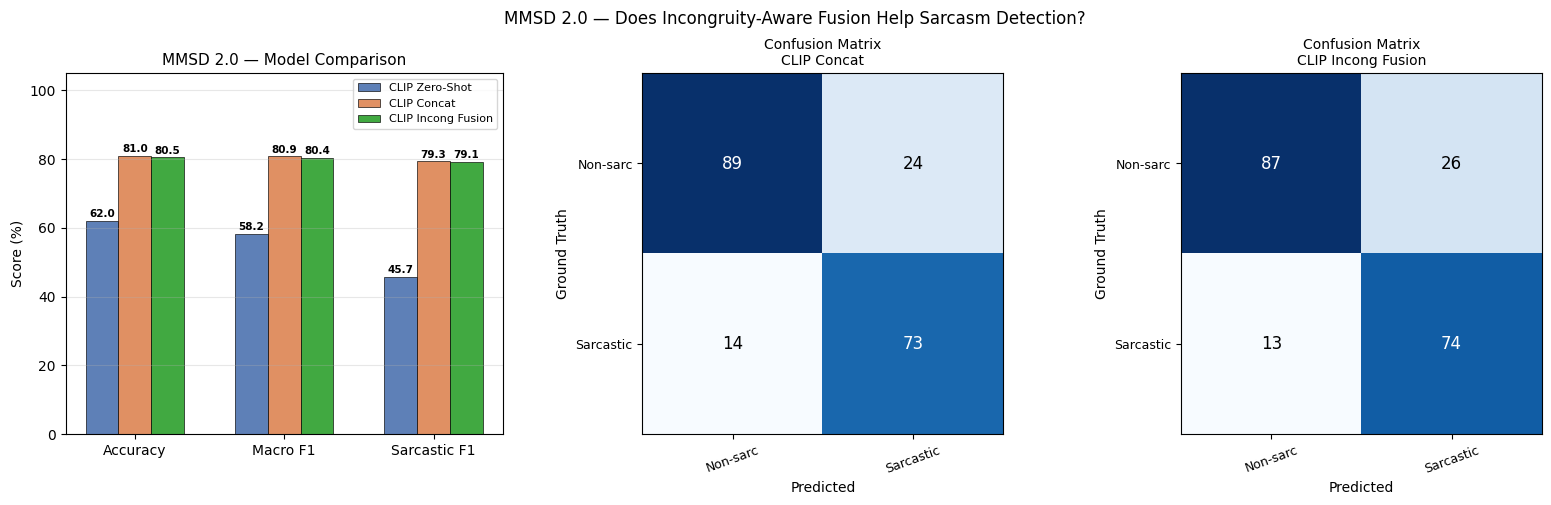

In [ ]:
# ── Comparison bar chart + confusion matrices ─────────────────────────────────
import itertools

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Bar chart ────────────────────────────────────────────────────────────────
ax = axes[0]
model_names = list(mmsd_results_cmp.keys())
metrics_to_plot = ['acc', 'macro_f1', 'sarc_f1']
metric_labels   = ['Accuracy', 'Macro F1', 'Sarcastic F1']
x = np.arange(len(metrics_to_plot))
width = 0.22
bar_colors = ['#4C72B0', '#DD8452', '#2ca02c']
for i, (name, color) in enumerate(zip(model_names, bar_colors)):
    vals = [mmsd_results_cmp[name][m] * 100 for m in metrics_to_plot]
    bars = ax.bar(x + (i - 1) * width, vals, width, label=name,
                  color=color, edgecolor='black', linewidth=0.5, alpha=0.9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{v:.1f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=10)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 105)
ax.set_title('MMSD 2.0 — Model Comparison', fontsize=11)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# ── Confusion matrices for Concat and IncongrFusion ───────────────────────────
class_names = ['Non-sarc', 'Sarcastic']
for ax, (name, preds, gts) in zip(axes[1:], [
    ('CLIP Concat',        concat_preds, concat_gts),
    ('CLIP Incong Fusion', incong_preds, incong_gts),
]):
    cm = np.zeros((2, 2), dtype=int)
    for p, g in zip(preds, gts):
        cm[g, p] += 1
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0,1]); ax.set_xticklabels(class_names, rotation=20, fontsize=9)
    ax.set_yticks([0,1]); ax.set_yticklabels(class_names, fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Ground Truth')
    ax.set_title(f'Confusion Matrix\n{name}', fontsize=10)
    for i, j in itertools.product(range(2), range(2)):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                color='white' if cm[i,j] > cm.max()*0.6 else 'black', fontsize=12)

plt.suptitle('MMSD 2.0 — Does Incongruity-Aware Fusion Help Sarcasm Detection?', fontsize=12)
plt.tight_layout()
plt.show()

---
## MET-Meme — Metaphor Task: CLIP-based Model Comparison

Binary classification: **0 = No metaphor**, **1 = Has metaphor**

We compare four model tiers on the metaphor field, all using the full test split:

| Model | Description |
|-------|-------------|
| **CLIP Zero-Shot** | Cosine similarity against text prompts, no training |
| **Unimodal-Image** | Frozen CLIP image tower + linear head, trained |
| **Unimodal-Text** | Frozen CLIP text tower + linear head, trained |
| **CLIP Concat** | Frozen CLIP img+txt concat (1024-d) → linear head |
| **CLIP Fusion** | Sentiment-Incongruity-Aware Fusion (CLIP encoders) |


In [1]:
# ── Setup: install CLIP and imports ─────────────────────────────────────────
!pip install -q git+https://github.com/openai/CLIP.git

import clip
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset, TensorDataset
from sklearn.metrics import accuracy_score, f1_score, classification_report
from datasets import load_dataset

device = 'cuda' if torch.cuda.is_available() else 'cpu'
clip_model, clip_preprocess = clip.load('ViT-B/32', device=device)
clip_model.eval()

# Load dataset (reuse hf if already loaded, else reload)
try:
    _ = hf
except NameError:
    from datasets import load_dataset
    hf = load_dataset('Emmaruyi/met-meme-filtered')

METAPHOR_LABELS = ['No metaphor', 'Has metaphor']  # indices 0, 1
NUM_METAPHOR_CLASSES = 2

print(f'Device: {device}')
print(f'Test split size: {len(hf["test"])}')


Device: cpu
Test split size: 340


### 1. CLIP Zero-Shot (Metaphor)

Use cosine similarity between image embeddings and text prompts for each class.

In [2]:
# ── CLIP Zero-Shot — Metaphor ────────────────────────────────────────────────
metaphor_prompts = [
    'a meme without any metaphor or figurative language',
    'a meme that uses metaphor or figurative language',
]

test_split = hf['test']
all_images = torch.stack([
    clip_preprocess(row['image'].convert('RGB')) for row in test_split
]).to(device)
true_metaphor = [row['metaphor_occurrence'] for row in test_split]

with torch.no_grad():
    meta_tokens = clip.tokenize(metaphor_prompts, truncate=True).to(device)
    meta_feats  = F.normalize(clip_model.encode_text(meta_tokens).float(), dim=-1)  # (2, 512)

    BATCH = 64
    all_preds_zs = []
    for start in range(0, len(all_images), BATCH):
        batch_imgs = all_images[start:start+BATCH]
        img_f = F.normalize(clip_model.encode_image(batch_imgs).float(), dim=-1)
        sims  = (img_f @ meta_feats.T).cpu().numpy()  # (B, 2)
        all_preds_zs.extend(sims.argmax(axis=1).tolist())

zs_acc = accuracy_score(true_metaphor, all_preds_zs)
zs_f1  = f1_score(true_metaphor, all_preds_zs, average='macro', zero_division=0)

print('=' * 55)
print(f'CLIP Zero-Shot — Metaphor (n={len(test_split)} test samples)')
print('=' * 55)
print(f'  Accuracy    : {zs_acc*100:.2f}%')
print(f'  Macro F1    : {zs_f1*100:.2f}%')
print(f'  Random base : 50.0%')
print()
print(classification_report(
    true_metaphor, all_preds_zs,
    target_names=METAPHOR_LABELS, zero_division=0
))


CLIP Zero-Shot — Metaphor (n=340 test samples)
  Accuracy    : 48.24%
  Macro F1    : 35.73%
  Random base : 50.0%

              precision    recall  f1-score   support

 No metaphor       0.21      0.04      0.07       156
Has metaphor       0.51      0.85      0.64       184

    accuracy                           0.48       340
   macro avg       0.36      0.45      0.36       340
weighted avg       0.37      0.48      0.38       340



### 2. Unimodal & Multimodal Trained Models (Metaphor)

Train CLIP-based models on the metaphor label. Backbone frozen, only classifier head is learned.

In [3]:
# ── CLIP Dataset for Metaphor ────────────────────────────────────────────────
import os

class MetaphorCLIPDataset(Dataset):
    def __init__(self, hf_split):
        self.data = hf_split

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row   = self.data[idx]
        image = clip_preprocess(row['image'].convert('RGB'))
        text  = clip.tokenize([row['caption']], truncate=True).squeeze(0)
        label = row['metaphor_occurrence']  # already 0/1
        return image, text, label

meta_trainset = MetaphorCLIPDataset(hf['train'])
meta_valset   = MetaphorCLIPDataset(hf['validation'])
meta_testset  = MetaphorCLIPDataset(hf['test'])

# Pre-cache CLIP embeddings for fast training
META_EMB_FILE = 'artifacts/clip_metaphor_emb.npz'
os.makedirs('artifacts', exist_ok=True)

def cache_embeddings(dataset, batch_size=64):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    all_img, all_txt, all_lbl = [], [], []
    clip_model.eval()
    with torch.no_grad():
        for imgs, texts, labels in loader:
            imgs, texts = imgs.to(device), texts.to(device)
            i_f = F.normalize(clip_model.encode_image(imgs).float(), dim=-1).cpu()
            t_f = F.normalize(clip_model.encode_text(texts).float(), dim=-1).cpu()
            all_img.append(i_f); all_txt.append(t_f); all_lbl.append(labels)
    return torch.cat(all_img), torch.cat(all_txt), torch.cat(all_lbl)

if os.path.exists(META_EMB_FILE):
    print('Loading cached metaphor CLIP embeddings...')
    d = np.load(META_EMB_FILE)
    tr_img = torch.from_numpy(d['tr_img']); tr_txt = torch.from_numpy(d['tr_txt']); tr_lbl = torch.from_numpy(d['tr_lbl'])
    va_img = torch.from_numpy(d['va_img']); va_txt = torch.from_numpy(d['va_txt']); va_lbl = torch.from_numpy(d['va_lbl'])
    te_img = torch.from_numpy(d['te_img']); te_txt = torch.from_numpy(d['te_txt']); te_lbl = torch.from_numpy(d['te_lbl'])
else:
    print('Caching CLIP embeddings for metaphor task...')
    tr_img, tr_txt, tr_lbl = cache_embeddings(meta_trainset)
    va_img, va_txt, va_lbl = cache_embeddings(meta_valset)
    te_img, te_txt, te_lbl = cache_embeddings(meta_testset)
    np.savez(META_EMB_FILE,
             tr_img=tr_img.numpy(), tr_txt=tr_txt.numpy(), tr_lbl=tr_lbl.numpy(),
             va_img=va_img.numpy(), va_txt=va_txt.numpy(), va_lbl=va_lbl.numpy(),
             te_img=te_img.numpy(), te_txt=te_txt.numpy(), te_lbl=te_lbl.numpy())
    print(f'Saved to {META_EMB_FILE}')

BATCH = 64
tr_loader = DataLoader(TensorDataset(tr_img, tr_txt, tr_lbl), batch_size=BATCH, shuffle=True)
va_loader = DataLoader(TensorDataset(va_img, va_txt, va_lbl), batch_size=BATCH)
te_loader = DataLoader(TensorDataset(te_img, te_txt, te_lbl), batch_size=BATCH)

print(f'Train: {len(tr_lbl)}, Val: {len(va_lbl)}, Test: {len(te_lbl)}')


Caching CLIP embeddings for metaphor task...
Saved to artifacts/clip_metaphor_emb.npz
Train: 2711, Val: 338, Test: 340


In [9]:
# ── Training & evaluation helpers ────────────────────────────────────────────
EPOCHS = 10
LR     = 5e-4
WD     = 1e-3

def train_linear(model, tr_loader, va_loader, ckpt_path, modality='both'):
    """Train a linear model on pre-cached CLIP embeddings with class-weighted loss."""
    if os.path.exists(ckpt_path):
        print(f'  Loading checkpoint {ckpt_path}')
        model.load_state_dict(torch.load(ckpt_path, map_location=device))
        return model
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)

    # Class-weighted loss to prevent collapse onto majority class
    all_labels = torch.cat([lbl for _, _, lbl in tr_loader])
    counts = torch.bincount(all_labels.long(), minlength=NUM_METAPHOR_CLASSES).float()
    weights = (1.0 / counts.clamp(min=1)).to(device)
    weights = weights / weights.sum() * NUM_METAPHOR_CLASSES
    criterion = nn.CrossEntropyLoss(weight=weights)

    best_val, best_state = 0.0, None
    for epoch in range(EPOCHS):
        model.train()
        for img_f, txt_f, lbl in tr_loader:
            img_f, txt_f, lbl = img_f.to(device), txt_f.to(device), lbl.long().to(device)
            opt.zero_grad()
            if modality == 'image':
                out = model(img_f)
            elif modality == 'text':
                out = model(txt_f)
            else:
                out = model(img_f, txt_f)
            criterion(out, lbl).backward()
            opt.step()
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for img_f, txt_f, lbl in va_loader:
                img_f, txt_f, lbl = img_f.to(device), txt_f.to(device), lbl.long().to(device)
                out = model(img_f) if modality == 'image' else (model(txt_f) if modality == 'text' else model(img_f, txt_f))
                correct += (out.argmax(1) == lbl).sum().item()
                total   += lbl.size(0)
        val_acc = correct / total
        if val_acc > best_val:
            best_val = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        print(f'    Epoch {epoch+1:02d} val_acc={val_acc:.4f}')
    model.load_state_dict(best_state)
    torch.save(best_state, ckpt_path)
    return model


def eval_model(model, te_loader, modality='both'):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for img_f, txt_f, lbl in te_loader:
            img_f, txt_f = img_f.to(device), txt_f.to(device)
            out = model(img_f) if modality == 'image' else (model(txt_f) if modality == 'text' else model(img_f, txt_f))
            preds.extend(out.argmax(1).cpu().tolist())
            trues.extend(lbl.tolist())
    acc = accuracy_score(trues, preds)
    f1  = f1_score(trues, preds, average='macro', zero_division=0)
    return acc, f1, trues, preds


print('Helpers defined.')


Helpers defined.


In [14]:
# ── Unimodal: Image-only (CLIP image tower + linear head) ────────────────────
img_uni = nn.Linear(512, NUM_METAPHOR_CLASSES)
img_uni = train_linear(
    img_uni, tr_loader, va_loader,
    ckpt_path='artifacts/metaphor_unimodal_image.pt',
    modality='image'
)
img_acc, img_f1, img_true, img_preds = eval_model(img_uni, te_loader, modality='image')
print(f'\nUnimodal-Image  — Accuracy: {img_acc*100:.2f}%  Macro-F1: {img_f1*100:.2f}%')
print(classification_report(img_true, img_preds, target_names=METAPHOR_LABELS, zero_division=0))

# ── Unimodal: Text-only (CLIP text tower + linear head) ──────────────────────
txt_uni = nn.Linear(512, NUM_METAPHOR_CLASSES)
txt_uni = train_linear(
    txt_uni, tr_loader, va_loader,
    ckpt_path='artifacts/metaphor_unimodal_text.pt',
    modality='text'
)
txt_acc, txt_f1, txt_true, txt_preds = eval_model(txt_uni, te_loader, modality='text')
print(f'\nUnimodal-Text   — Accuracy: {txt_acc*100:.2f}%  Macro-F1: {txt_f1*100:.2f}%')
print(classification_report(txt_true, txt_preds, target_names=METAPHOR_LABELS, zero_division=0))


  Loading checkpoint artifacts/metaphor_unimodal_image.pt

Unimodal-Image  — Accuracy: 79.12%  Macro-F1: 79.12%
              precision    recall  f1-score   support

 No metaphor       0.73      0.86      0.79       156
Has metaphor       0.86      0.73      0.79       184

    accuracy                           0.79       340
   macro avg       0.80      0.80      0.79       340
weighted avg       0.80      0.79      0.79       340

  Loading checkpoint artifacts/metaphor_unimodal_text.pt

Unimodal-Text   — Accuracy: 73.82%  Macro-F1: 73.80%
              precision    recall  f1-score   support

 No metaphor       0.67      0.84      0.75       156
Has metaphor       0.83      0.65      0.73       184

    accuracy                           0.74       340
   macro avg       0.75      0.75      0.74       340
weighted avg       0.76      0.74      0.74       340



In [15]:
# ── CLIP Concat: concat(img, txt) → linear head ──────────────────────────────
class ConcatClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.head = nn.Linear(1024, num_classes)

    def forward(self, img_f, txt_f):
        return self.head(torch.cat([img_f, txt_f], dim=-1))

concat_model = ConcatClassifier(num_classes=NUM_METAPHOR_CLASSES)
concat_model = train_linear(
    concat_model, tr_loader, va_loader,
    ckpt_path='artifacts/metaphor_concat.pt',
    modality='both'
)
cat_acc, cat_f1, cat_true, cat_preds = eval_model(concat_model, te_loader, modality='both')
print(f'\nCLIP Concat     — Accuracy: {cat_acc*100:.2f}%  Macro-F1: {cat_f1*100:.2f}%')
print(classification_report(cat_true, cat_preds, target_names=METAPHOR_LABELS, zero_division=0))


  Loading checkpoint artifacts/metaphor_concat.pt

CLIP Concat     — Accuracy: 81.76%  Macro-F1: 81.75%
              precision    recall  f1-score   support

 No metaphor       0.77      0.86      0.81       156
Has metaphor       0.87      0.78      0.82       184

    accuracy                           0.82       340
   macro avg       0.82      0.82      0.82       340
weighted avg       0.82      0.82      0.82       340



In [16]:
# ── CLIP Sentiment-Incongruity-Aware Fusion ──────────────────────────────────
# Reuses the SentimentIncongruityFusion architecture from incongruity_aware_fusion.ipynb
# Re-defined here for standalone use in this notebook.

class SentimentIncongruityFusion(nn.Module):
    """
    Projects each modality into sentiment probability space,
    then computes emotional disagreement as an incongruity signal.
    """
    def __init__(self, input_dim=64, num_sentiments=7):
        super().__init__()
        self.img_sent = nn.Linear(input_dim, num_sentiments)
        self.txt_sent = nn.Linear(input_dim, num_sentiments)

    def forward(self, img_proj, txt_proj):
        img_s = torch.softmax(self.img_sent(img_proj), dim=-1)  # (B, num_sentiments)
        txt_s = torch.softmax(self.txt_sent(txt_proj), dim=-1)
        incong = torch.abs(img_s - txt_s)                       # (B, num_sentiments)
        # align projection: element-wise product of the two sentiment vectors
        align  = img_s * txt_s                                   # (B, num_sentiments)
        return torch.cat([align, incong, img_proj, txt_proj], dim=-1)  # corrected shape below


class CLIPProjection(nn.Module):
    """Frozen CLIP encoder + trainable projection to output_dim."""
    def __init__(self, output_dim=64, modality='image'):
        super().__init__()
        self.proj     = nn.Linear(512, output_dim)
        self.modality = modality

    def forward(self, x):
        # x is already a normalized CLIP embedding (from cache)
        return self.proj(x)


class FusionClassifier(nn.Module):
    """Full CLIP incongruity fusion model operating on pre-cached embeddings."""
    def __init__(self, proj_dim=64, num_sentiments=7, num_classes=2):
        super().__init__()
        self.img_proj = CLIPProjection(proj_dim, 'image')
        self.txt_proj = CLIPProjection(proj_dim, 'text')
        self.fusion   = SentimentIncongruityFusion(proj_dim, num_sentiments)
        # fusion output dim: 2*num_sentiments (align+incong) + 2*proj_dim (img_proj+txt_proj)
        fused_dim = 2 * num_sentiments + 2 * proj_dim
        self.head = nn.Sequential(
            nn.Linear(fused_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, img_f, txt_f):
        ip = self.img_proj(img_f)
        tp = self.txt_proj(txt_f)
        fused = self.fusion(ip, tp)  # (B, 2*num_sentiments + 2*proj_dim)
        return self.head(fused)


fusion_model = FusionClassifier(
    proj_dim=64, num_sentiments=7, num_classes=NUM_METAPHOR_CLASSES
)
fusion_model = train_linear(
    fusion_model, tr_loader, va_loader,
    ckpt_path='artifacts/metaphor_clip_fusion.pt',
    modality='both'
)
fus_acc, fus_f1, fus_true, fus_preds = eval_model(fusion_model, te_loader, modality='both')
print(f'\nCLIP Fusion     — Accuracy: {fus_acc*100:.2f}%  Macro-F1: {fus_f1*100:.2f}%')
print(classification_report(fus_true, fus_preds, target_names=METAPHOR_LABELS, zero_division=0))


  Loading checkpoint artifacts/metaphor_clip_fusion.pt

CLIP Fusion     — Accuracy: 86.47%  Macro-F1: 86.47%
              precision    recall  f1-score   support

 No metaphor       0.79      0.96      0.87       156
Has metaphor       0.95      0.79      0.86       184

    accuracy                           0.86       340
   macro avg       0.87      0.87      0.86       340
weighted avg       0.88      0.86      0.86       340



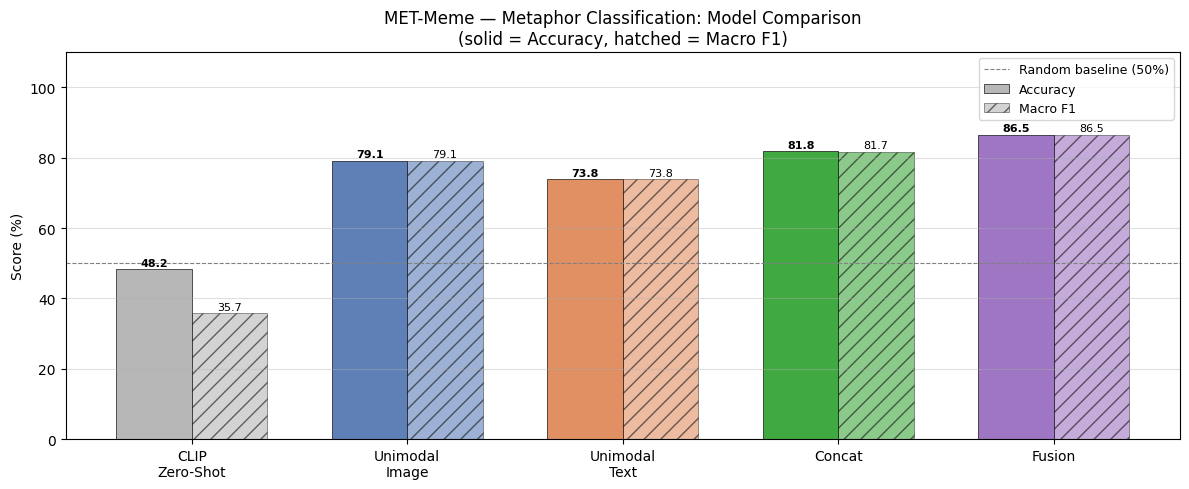

METAPHOR TASK — Model Comparison Summary
Model                       Accuracy    Macro F1
--------------------------------------------------
CLIP Zero-Shot                48.24%      35.73%
Unimodal Image                79.12%      79.12%
Unimodal Text                 73.82%      73.80%
Concat                        81.76%      81.75%
Fusion                        86.47%      86.47%


In [17]:
# ── Summary comparison: all models on metaphor task ──────────────────────────
# Also include LLM zero-shot results for GPT-4o and Gemini-2.5-Flash (from cell 9)
try:
    llm_gpt_acc  = metrics['GPT-4o']['metaphor']['accuracy']
    llm_gem_acc  = metrics['Gemini-2.5-Flash']['metaphor']['accuracy']
    llm_gpt_f1   = metrics['GPT-4o']['metaphor']['macro_f1']
    llm_gem_f1   = metrics['Gemini-2.5-Flash']['metaphor']['macro_f1']
    has_llm = True
except Exception:
    has_llm = False

model_labels = ['CLIP\nZero-Shot', 'Unimodal\nImage', 'Unimodal\nText', 'Concat', 'Fusion']
accs = [zs_acc, img_acc, txt_acc, cat_acc, fus_acc]
f1s  = [zs_f1,  img_f1,  txt_f1,  cat_f1,  fus_f1]

if has_llm:
    model_labels = ['GPT-4o\n(LLM)', 'Gemini\n(LLM)'] + model_labels
    accs = [llm_gpt_acc, llm_gem_acc] + accs
    f1s  = [llm_gpt_f1,  llm_gem_f1]  + f1s


colors = (['#e05c5c', '#e07c2c'] if has_llm else []) + [
    '#b0b0b0', '#4C72B0', '#DD8452', '#2ca02c', '#9467bd'
]

x = np.arange(len(model_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, [a*100 for a in accs], width, label='Accuracy',  color=colors, alpha=0.9, edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, [f*100 for f in f1s],  width, label='Macro F1', color=colors, alpha=0.55, edgecolor='black', linewidth=0.5, hatch='//')

for bar, val in zip(bars1, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val*100:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
for bar, val in zip(bars2, f1s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val*100:.1f}', ha='center', va='bottom', fontsize=8)

ax.axhline(50, color='gray', linestyle='--', linewidth=0.8, label='Random baseline (50%)')
ax.set_xticks(x)
ax.set_xticklabels(model_labels, fontsize=10)
ax.set_ylabel('Score (%)')
ax.set_title('MET-Meme — Metaphor Classification: Model Comparison\n(solid = Accuracy, hatched = Macro F1)')
ax.set_ylim(0, 110)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('results/metaphor_model_comparison.png', dpi=150)
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print('=' * 55)
print('METAPHOR TASK — Model Comparison Summary')
print('=' * 55)
print(f'{"Model":<25} {"Accuracy":>10}  {"Macro F1":>10}')
print('-' * 50)
for lbl, acc, f1 in zip(model_labels, accs, f1s):
    clean_lbl = lbl.replace('\\n', ' ').replace('\n', ' ')
    print(f'{clean_lbl:<25} {acc*100:>9.2f}%  {f1*100:>9.2f}%')
